In [1]:
# jax ecosystem
import jax

# jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)
print(jax.local_devices()[0].device_kind)

from jax import numpy as np, tree as jtu
import zodiax as zdx
from amigo.fitting import sgd, adam
import amigo
import dorito

# other helpful libraries
import numpy
import os
import astropy

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots  # to use matplotlib style "science"

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

cpu


In [2]:
from socket import gethostname

print(gethostname())
if gethostname() == "glinton":
    path = "/media/morgana1/snert/max/"
elif (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    path = "/Volumes/morgana1/snert/max/"
    # path = "/Volumes/research-data/PRJ-PAT/max/"
else:
    path = "/fred/oz440/max/"

source_name = "PDS70"
data_path = os.path.join(path, f"data/JWST/{source_name}/calslope/")
uncal_path = os.path.join(path, f"data/JWST/{source_name}/uncal/")
amigo_cache = os.path.join(path, "data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, f"outputs/{source_name}/")

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    "F430M",
    "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

maxs-mbp-14.shared.sydney.edu.au



# Loading in data

In [3]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
sci_files = []
cal_files = []

for file in files:

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1

    if file[0].header["TARGPROP"] == "TD-PDS-70":
        # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
        file["BADPIX"].data[17, 70] = 1
        file["BADPIX"].data[64, 17] = 1
        file["BADPIX"].data[19, 53] = 1
        file["BADPIX"].data[5, 22] = 1
        file["BADPIX"].data[19, 41] = 1
        # file["BADPIX"].data[:66, :25] = 1  # BACKGROUND STAR?
        file["BADPIX"].data[76, 45] = 1
        file["BADPIX"].data[59, 30] = 1

    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        # file[0].header["TARGPROP"] = "HD228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(sci_files, 30)

In [4]:
from astropy.time import Time

t0 = Time(0, format="mjd")
for file in files:
    h = file[0].header
    t = Time(h["EXPMID"], format="mjd")

    if t.ymdhms[2] != t0.ymdhms[2]:
        print("\n" + 30 * "-" + "\n")

    print(
        f'{h["TARGPROP"]} {h["FILTER"]}, Dither {h["PATT_NUM"]}/{h["NUMDTHPT"]}, Roll {h["ROLL_REF"]:.1f}deg, {h["XPOSURE"] / 60:.1f}min, {t.iso}, Groups: {h["NGROUPS"]}, Ints: {h["NINTS"]}, PWCPOS {h["PWCPOS"]}'
    )
    t0 = t


------------------------------

TD-CAL-HD-123991 F480M, Dither 1/1, Roll 302.2deg, 15.2min, 2023-02-24 19:20:07.785, Groups: 29, Ints: 418, PWCPOS 205.0233309999992
TD-CAL-HD-123991 F430M, Dither 1/1, Roll 302.2deg, 12.7min, 2023-02-24 19:36:30.612, Groups: 20, Ints: 507, PWCPOS 205.0233309999996
TD-CAL-HD-123991 F380M, Dither 1/1, Roll 302.2deg, 7.7min, 2023-02-24 19:49:00.589, Groups: 10, Ints: 612, PWCPOS 205.02333100000027
TD-PDS-70 F480M, Dither 1/1, Roll 301.7deg, 50.5min, 2023-02-24 21:05:08.000, Groups: 96, Ints: 418, PWCPOS 204.98422199999922
TD-PDS-70 F430M, Dither 1/1, Roll 301.7deg, 40.4min, 2023-02-24 21:52:27.644, Groups: 64, Ints: 502, PWCPOS 204.98666399999735
TD-PDS-70 F380M, Dither 1/1, Roll 301.7deg, 36.8min, 2023-02-24 22:33:15.992, Groups: 49, Ints: 597, PWCPOS 204.99400000000205


/Users/mc/miniconda3/envs/retrain/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


## Building the model

In [5]:
import dLux as dl
from dLux import utils as dlu
from amigo.model_fits import PointFit, SplineVisFit
from dorito.model_fits import PointResolvedFit


class PDS70VisFit(PointResolvedFit):
    # class PDS70VisFit(SplineVisFit):
    """
    So this is going to have the visibilities soak up the main star and resolved
    component, and have a second independent point source.
    """

    sub_exps: dict
    unique_params: list

    def __init__(self, file, **kwargs):

        super().__init__(file, **kwargs)

        self.sub_exps = {
            # "A": PointFit(file),
            "A": PointResolvedFit(file),
            # "A": SplineVisFit(file),
            "B": PointFit(file),
        }

        unique_params = [
            "positions",
            "fluxes",
            "spectra",
        ]
        self.unique_params = unique_params

    def initialise_params(self, optics, **kwargs):
        # def initialise_params(self, optics, vis_model=None, one_on_fs_order=1):
        params = super().initialise_params(
            optics,
            # one_on_fs_order=one_on_fs_order,
            **kwargs,
            # vis_model=vis_model,
        )
        for param, (key, value) in params.items():
            if param in self.unique_params:
                params[param] = key, np.array(2 * [value])  # one for each source

        return params

    # def get_key(self, param):
    #     return super().get_key(param)

    # def map_param(self, param):
    #     return super().map_param(param)

    def model_joint_ramp(self, model):

        # unpacking the unique parameters for each source
        modelA = model
        modelB = model

        for param in self.unique_params:
            pA, pB = model.get(self.map_param(param))
            modelA = modelA.set(self.map_param(param), pA)
            modelB = modelB.set(self.map_param(param), pB)

        # TODO Vectorise this!!!
        illuminances = []

        # "A", PDS70 with resolved component
        psf = self.sub_exps["A"].model_psf(modelA)
        interferogram = self.sub_exps["A"].model_interferogram(psf, modelA)
        illuminance = self.sub_exps["A"].model_illuminance(interferogram, modelA)
        illuminances.append(illuminance.data)

        # "B", background star
        psf = self.sub_exps["B"].model_psf(modelB)
        illuminance = self.sub_exps["B"].model_illuminance(psf, modelB)
        illuminances.append(illuminance.data)

        illuminance = dl.PSF(np.array(illuminances).sum(axis=0), psf.pixel_scale)

        ramp = self.model_ramp(illuminance, model)
        ramp = self.model_read(ramp, model)

        return ramp

    def simulate(self, model, return_slopes: bool = True):

        ramp = self.model_joint_ramp(model)

        if return_slopes:
            return ramp.set("data", np.diff(ramp.data, axis=0))
        return ramp

In [6]:
from amigo.model_fits import PointFit, SplineVisFit
from dorito.models import ResolvedAmigoModel

load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

# just two science exposures and one calibrator for this demo
sci_exps = [PDS70VisFit(file) for file in sci_files]
# sci_exps = [PDS70VisFit(file, use_cov=True) for file in sci_files]
fish_sci_exps = [PointResolvedFit(file) for file in sci_files]
# fish_sci_exps = [SplineVisFit(file, use_cov=True) for file in sci_files]
# sci_exps = [PointFit(file, use_cov=True) for file in sci_files]
cal_exps = [PointFit(file) for file in cal_files]
# cal_exps = [SplineVisFit(file) for file in cal_files]

exposures = sci_exps + cal_exps
# exposures = sci_exps  # + cal_exps
# exposures = fish_sci_exps  # + cal_exps
# fish_exposures = fish_sci_exps + cal_exps
fish_exposures = fish_sci_exps  # + cal_exps

source_size = 81  # pixels
init_dist = np.ones((source_size, source_size)) / 81**2

# building the model
model = ResolvedAmigoModel(
    # model = amigo.core_models.AmigoModel(
    exposures=exposures,
    optics=amigo.optical_models.AMIOptics(),
    detector=amigo.detector_models.LinearDetector(),
    ramp_model=amigo.ramp_models.NonLinearRamp(),
    read=amigo.read_models.ReadModel(),
    # vis_model=amigo.vis_models.LogVisModel(
    #     load_dict(cache + "vis_basis.npy"), n_basis=420
    # ),
    state=load_dict(cache + "calibration.npy"),
    # param_initers={"contrast": 0.9, "coeffs": np.log10(init_dist)},  # for testing
    param_initers={"contrast": 0.04, "coeffs": np.log10(init_dist)},
)

# Changing the initial parameters for the background star!
init_fluxes = model.params["fluxes"]["01242_005_02_03_1"]
init_fluxes = model.params["fluxes"]["01242_005_03_03_1"]
init_fluxes = model.params["fluxes"]["01242_005_04_03_1"]
model.params["fluxes"]["01242_005_02_03_1"] = init_fluxes.at[1].set(np.array(2.1))
model.params["fluxes"]["01242_005_03_03_1"] = init_fluxes.at[1].set(np.array(2.1))
model.params["fluxes"]["01242_005_04_03_1"] = init_fluxes.at[1].set(np.array(2.1))

init_pos = model.params["positions"]["01242_005_02_03_1"]
init_pos = model.params["positions"]["01242_005_03_03_1"]
init_pos = model.params["positions"]["01242_005_04_03_1"]
model.params["positions"]["01242_005_02_03_1"] = init_pos.at[1].set(
    np.array([-2.15, -0.71])
)
model.params["positions"]["01242_005_03_03_1"] = init_pos.at[1].set(
    np.array([-2.15, -0.71])
)
model.params["positions"]["01242_005_04_03_1"] = init_pos.at[1].set(
    np.array([-2.15, -0.71])
)

# For odel = mthe fishers
fish_params = jax.tree.map(lambda x: x, model.params)
fish_params["fluxes"]["01242_005_02_03_1"] = init_fluxes[0]
fish_params["fluxes"]["01242_005_03_03_1"] = init_fluxes[0]
fish_params["fluxes"]["01242_005_04_03_1"] = init_fluxes[0]
fish_model = model.set("params", fish_params)

File 01242_005_02_03_1
Star TD-PDS-70
Filter F480M
nints 418
ngroups 96



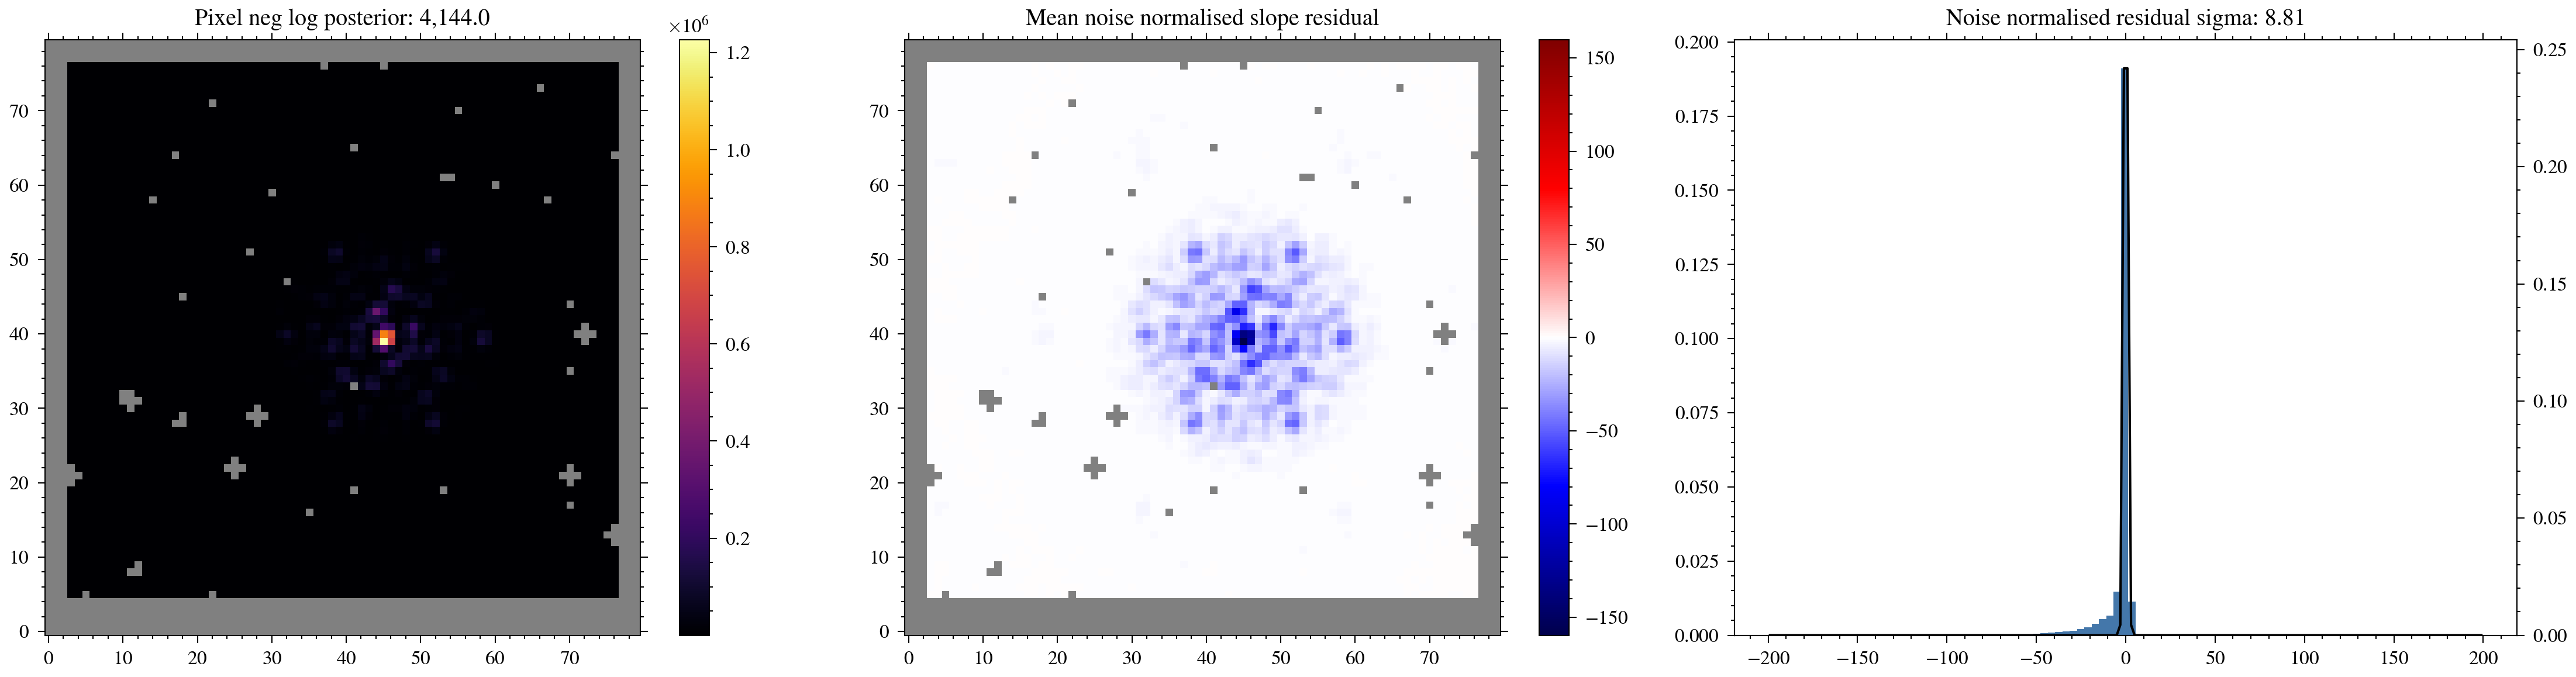

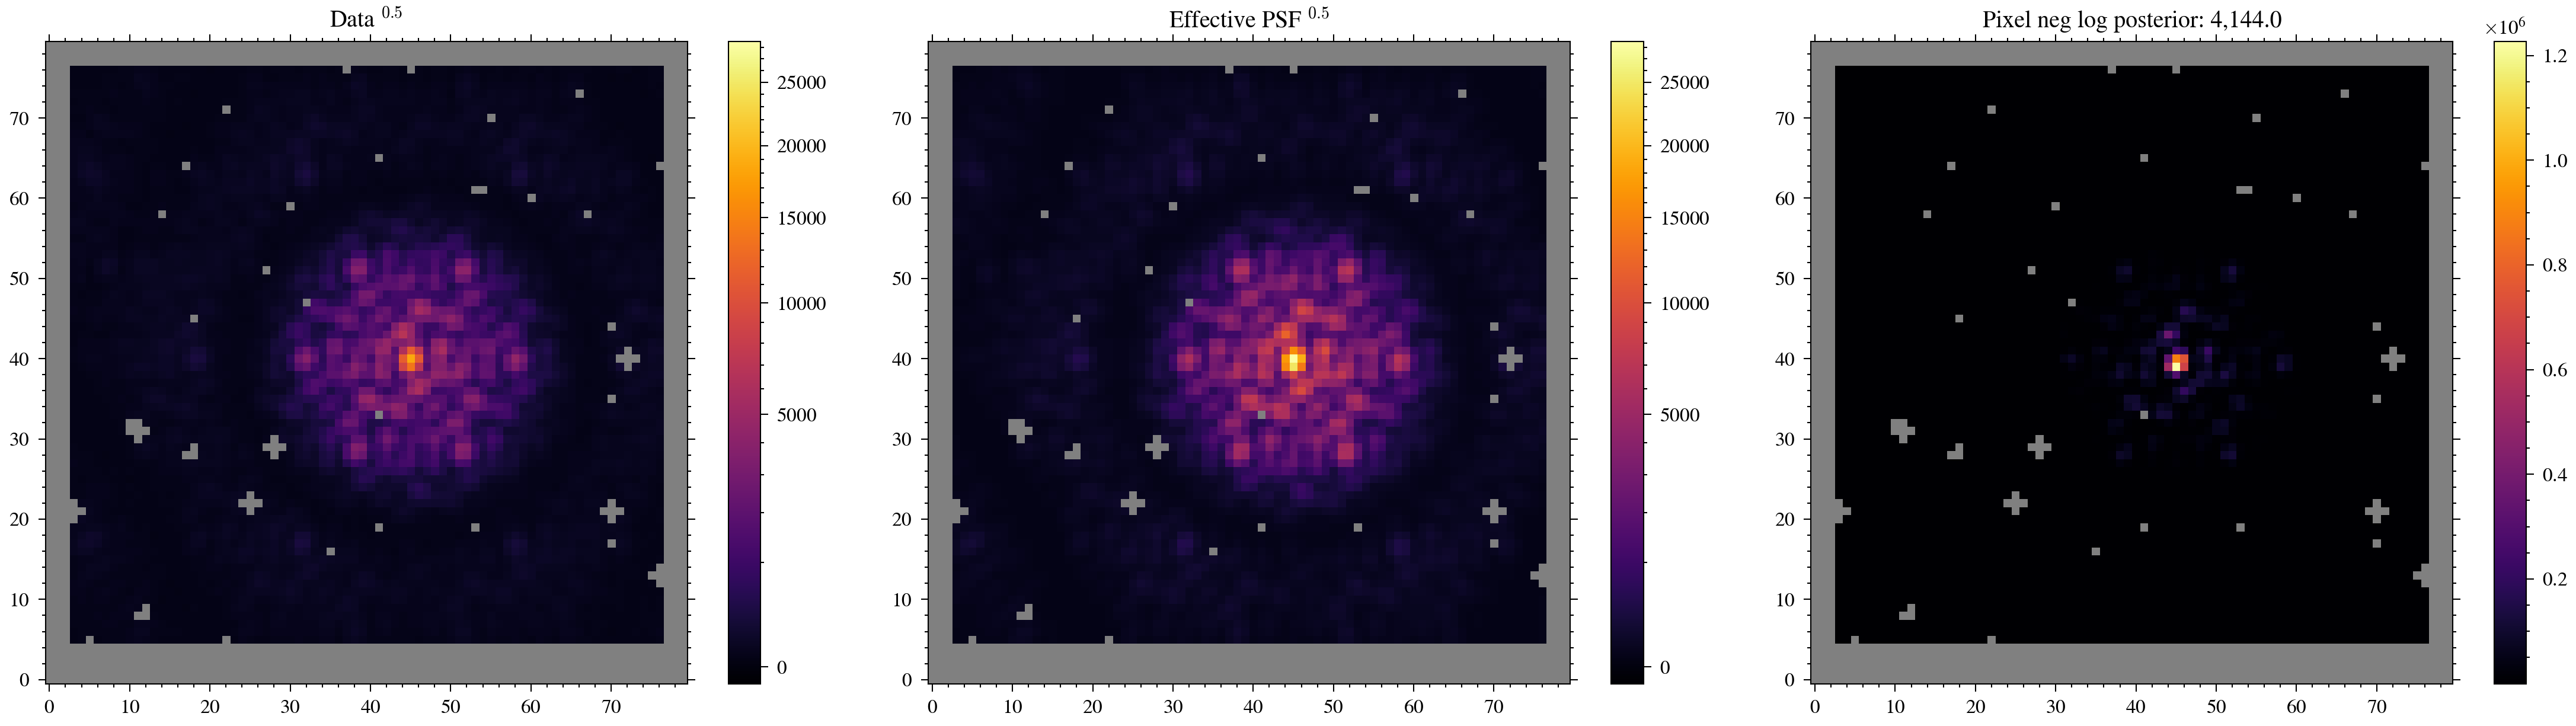

File 01242_005_03_03_1
Star TD-PDS-70
Filter F430M
nints 502
ngroups 64



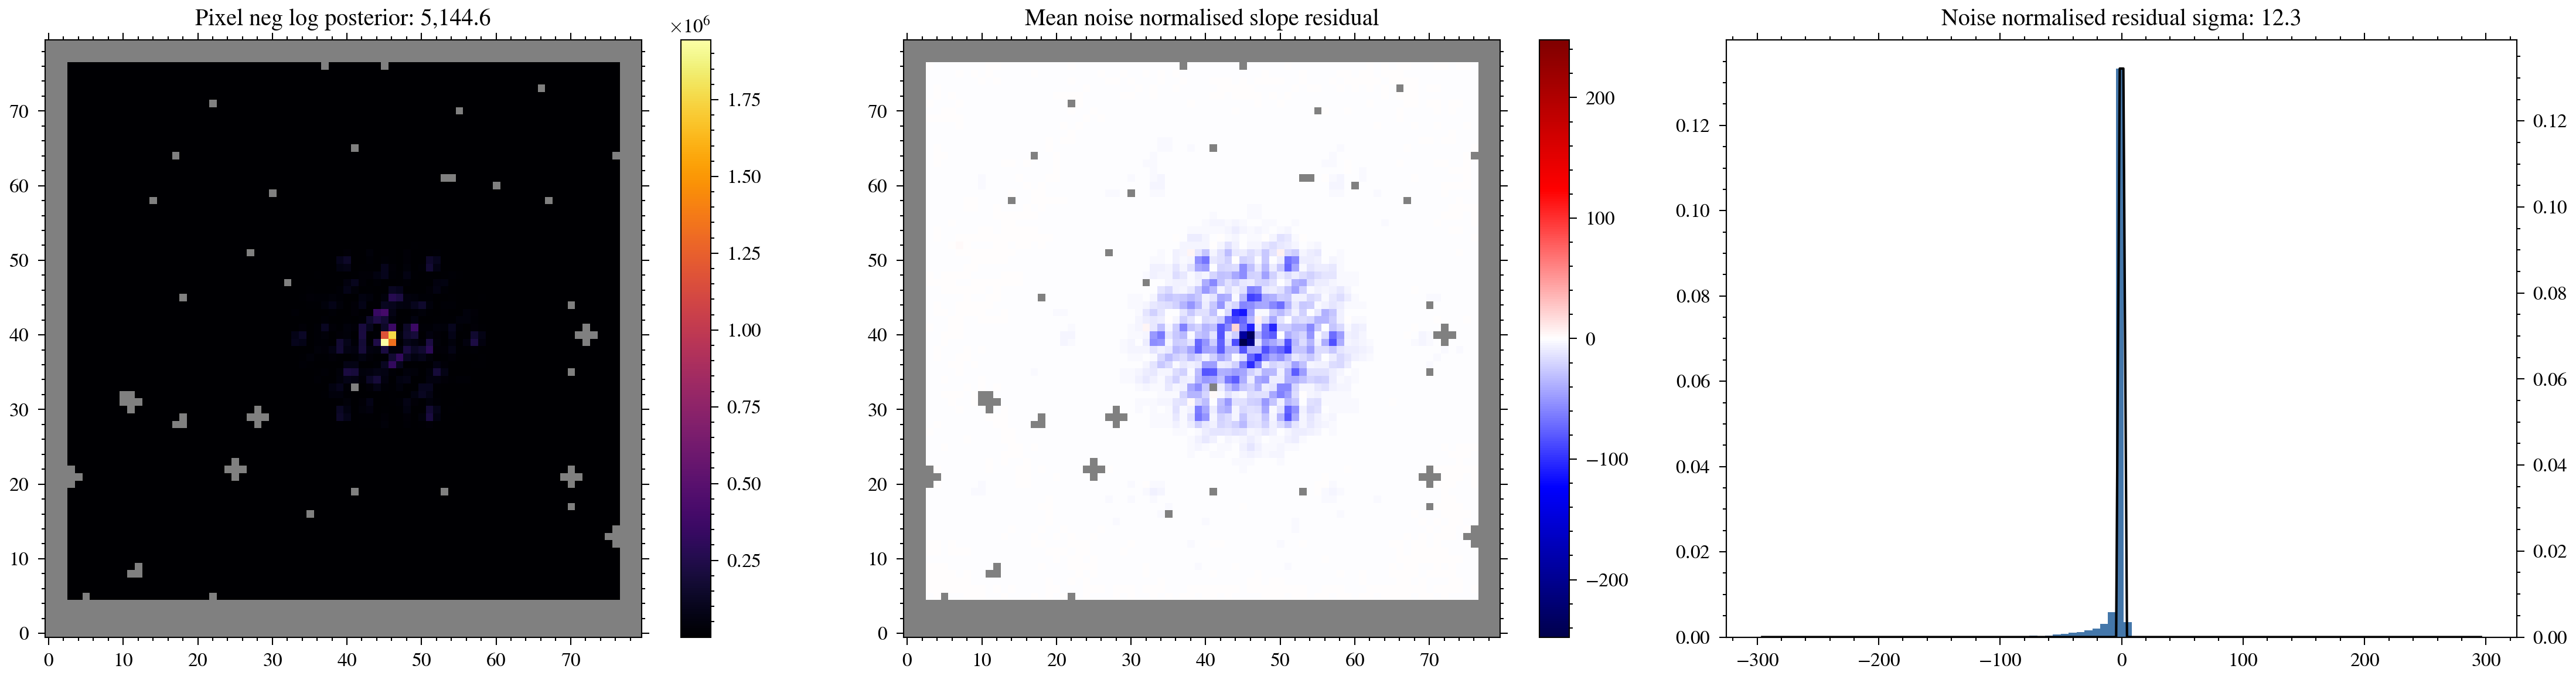

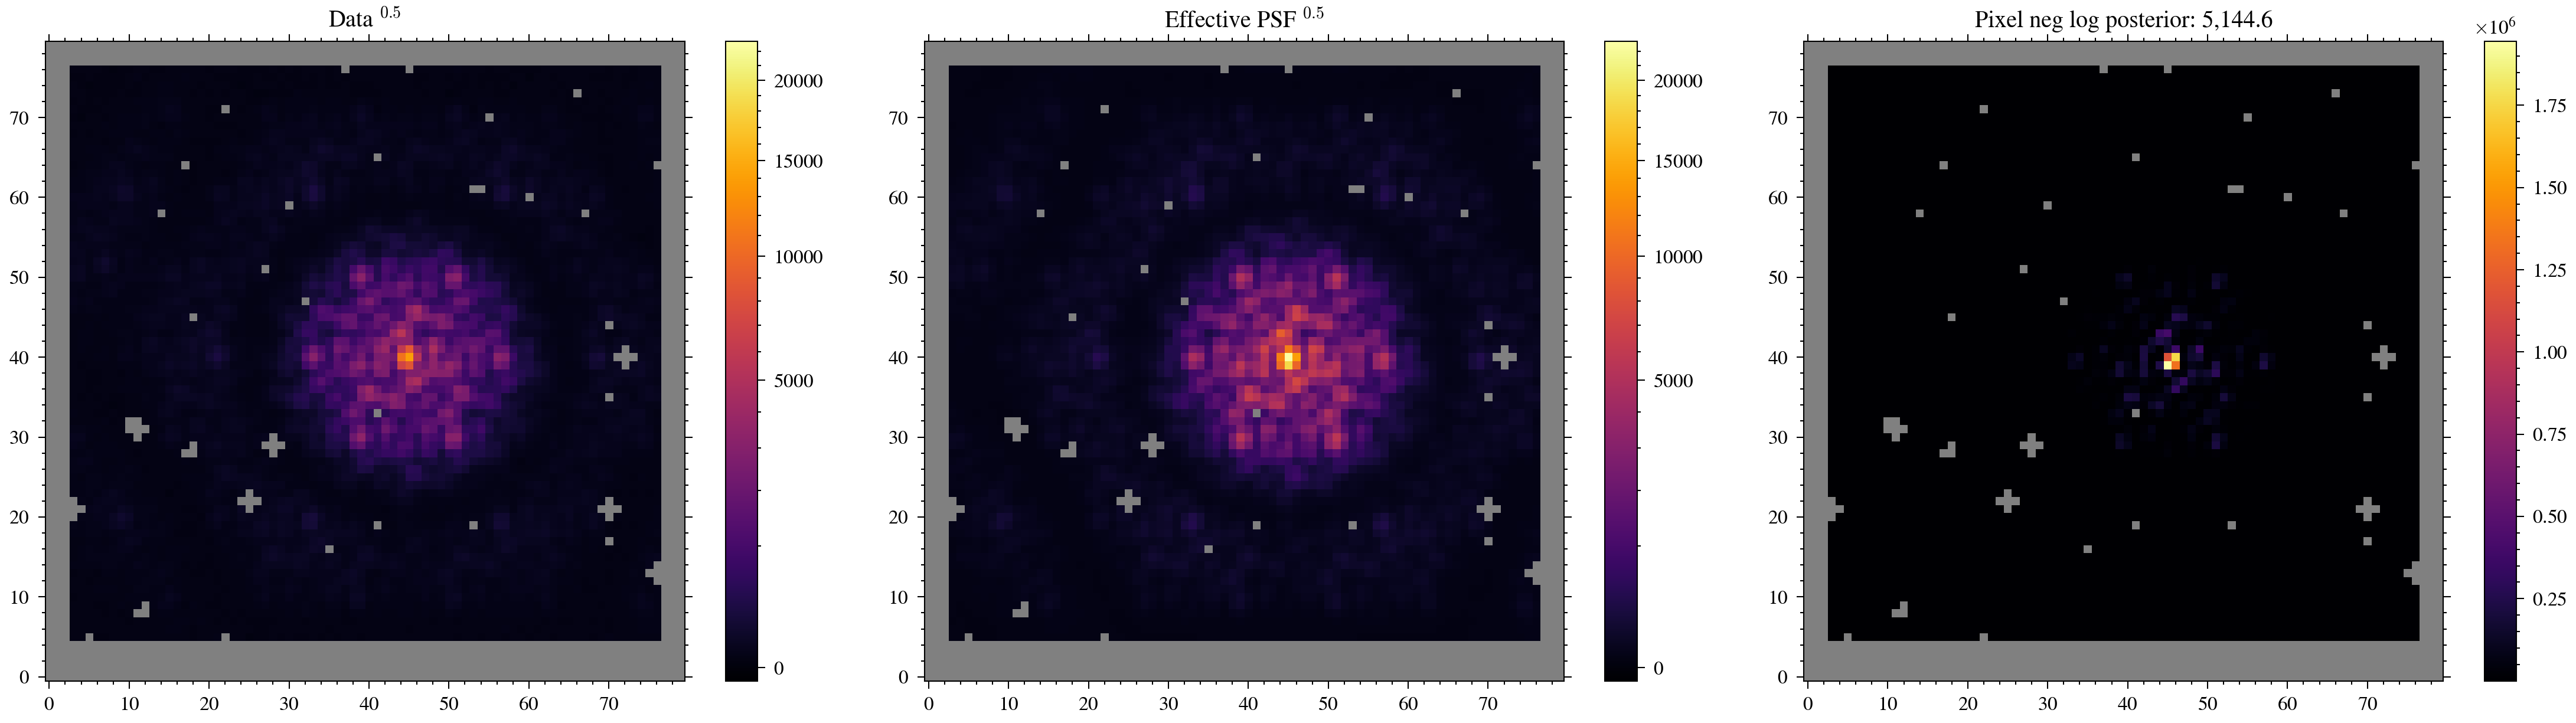

File 01242_005_04_03_1
Star TD-PDS-70
Filter F380M
nints 597
ngroups 49



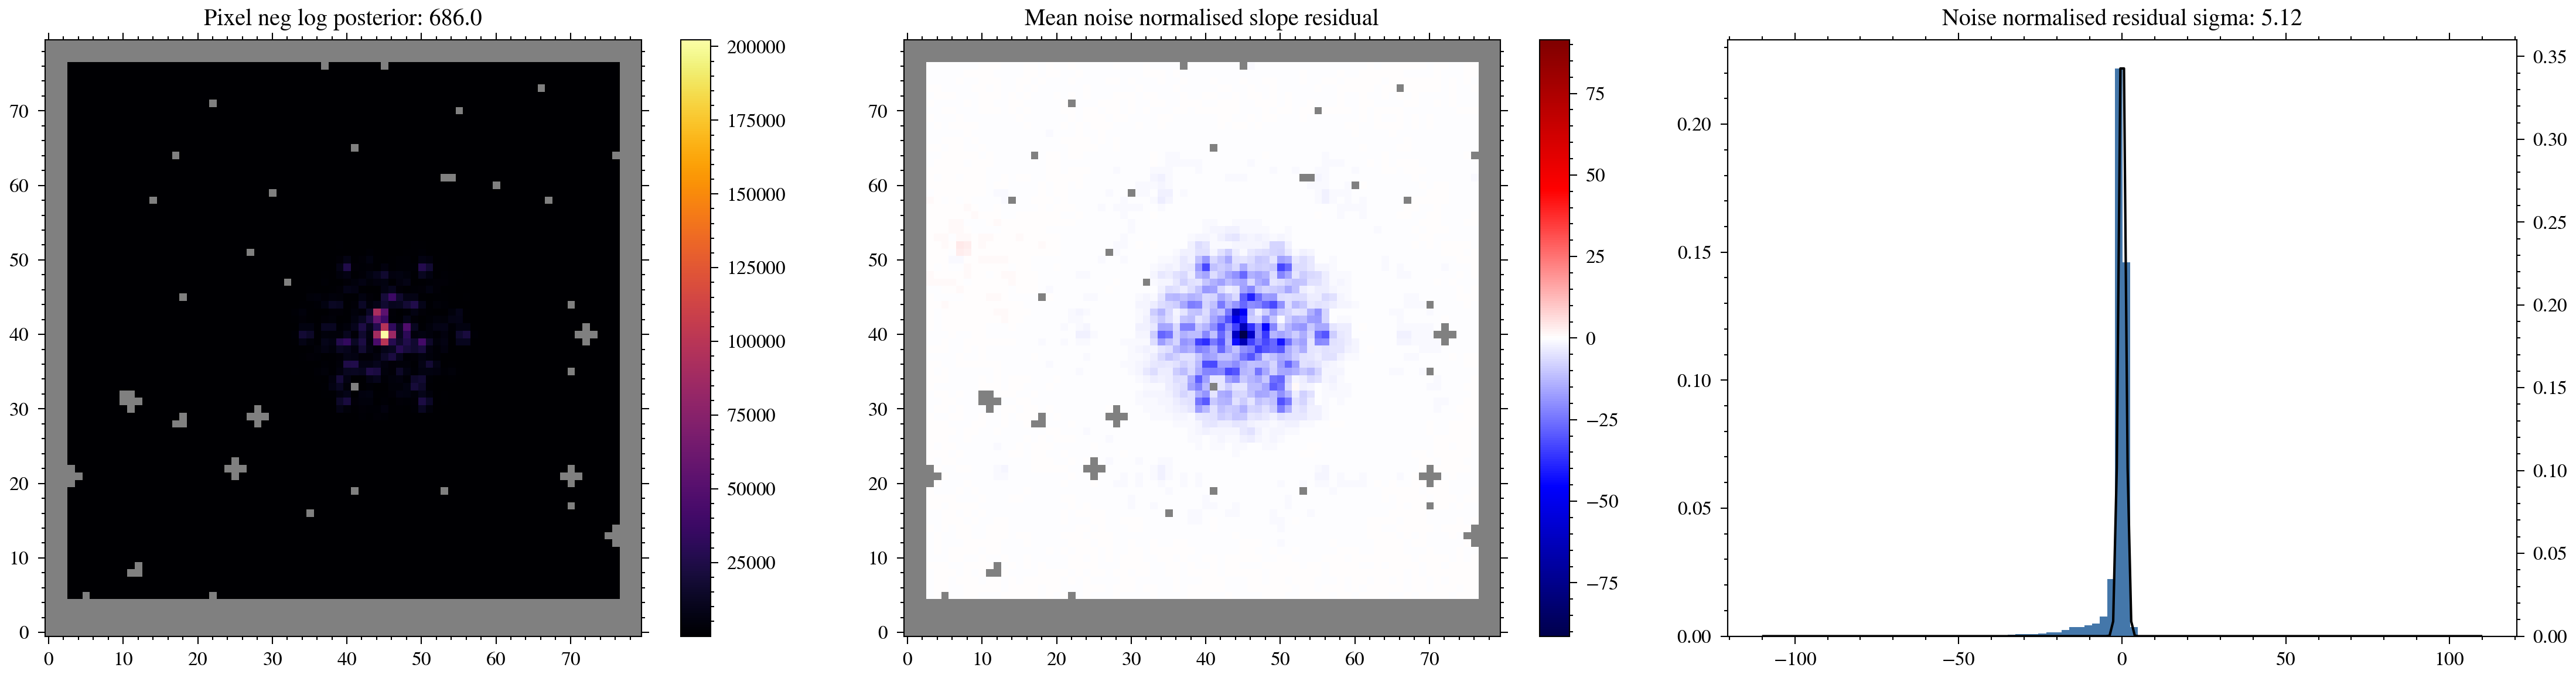

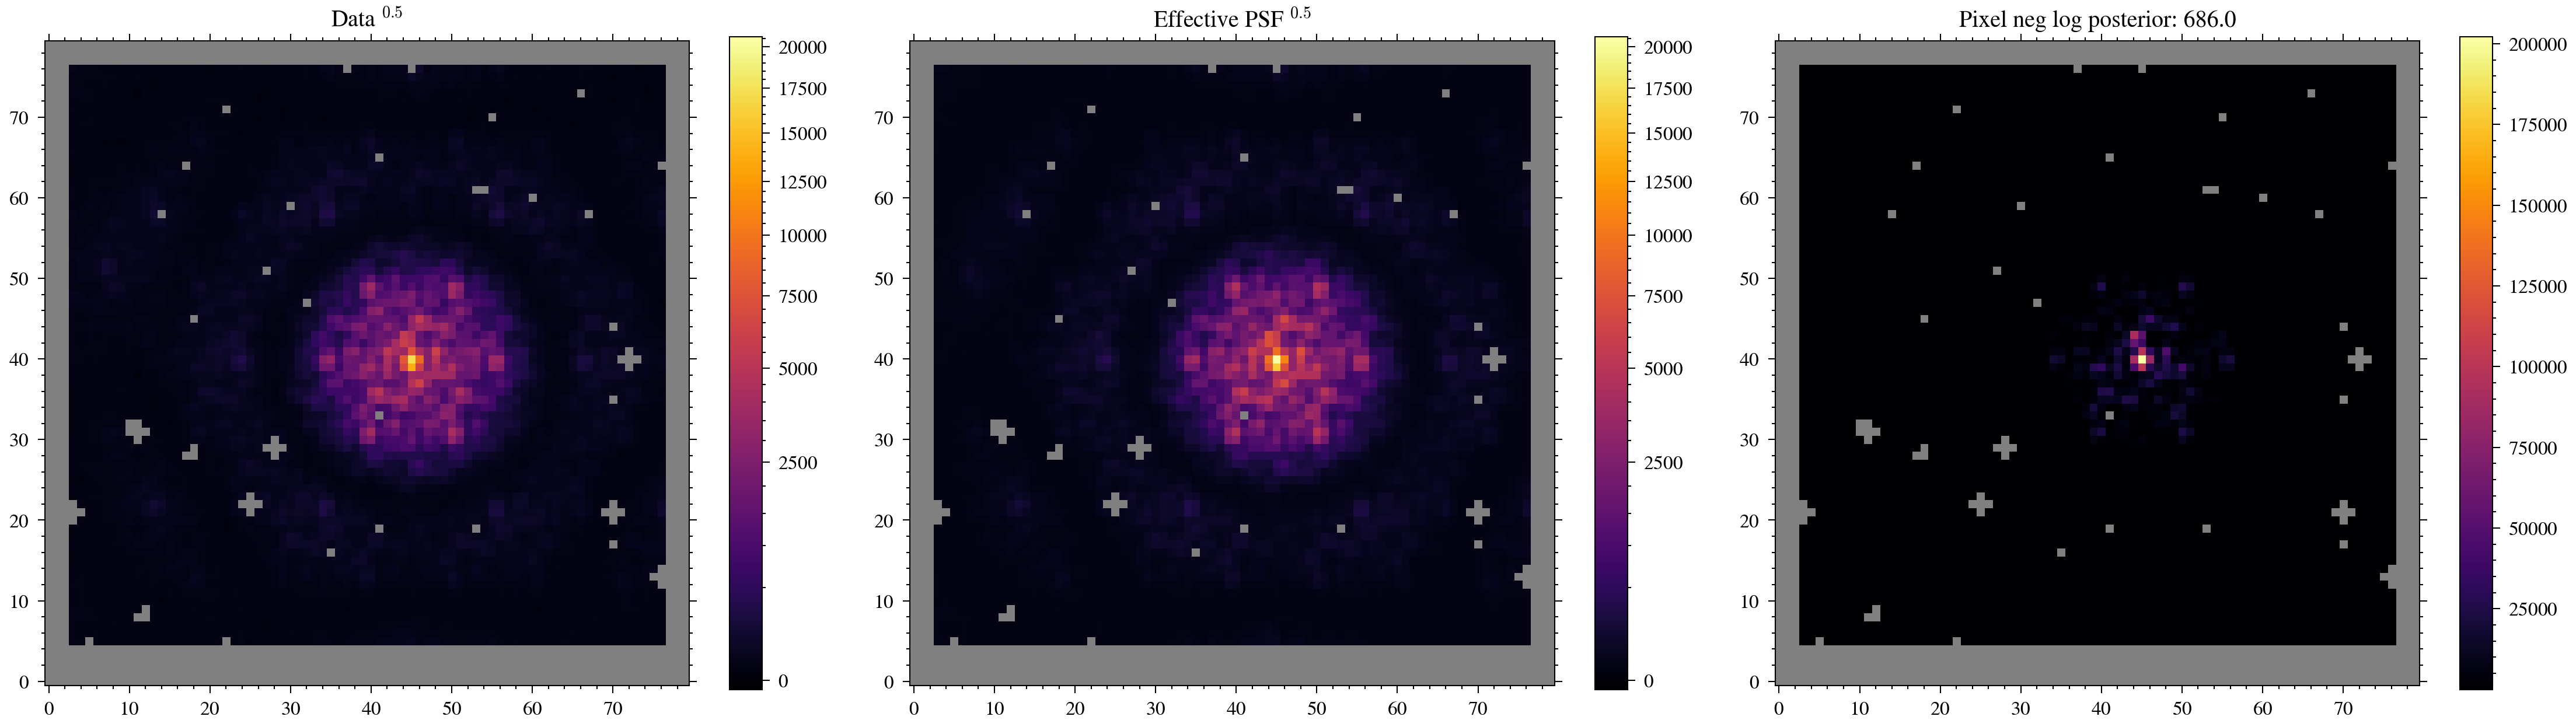

File 01242_004_02_03_1
Star TD-CAL-HD-123991
Filter F480M
nints 418
ngroups 29



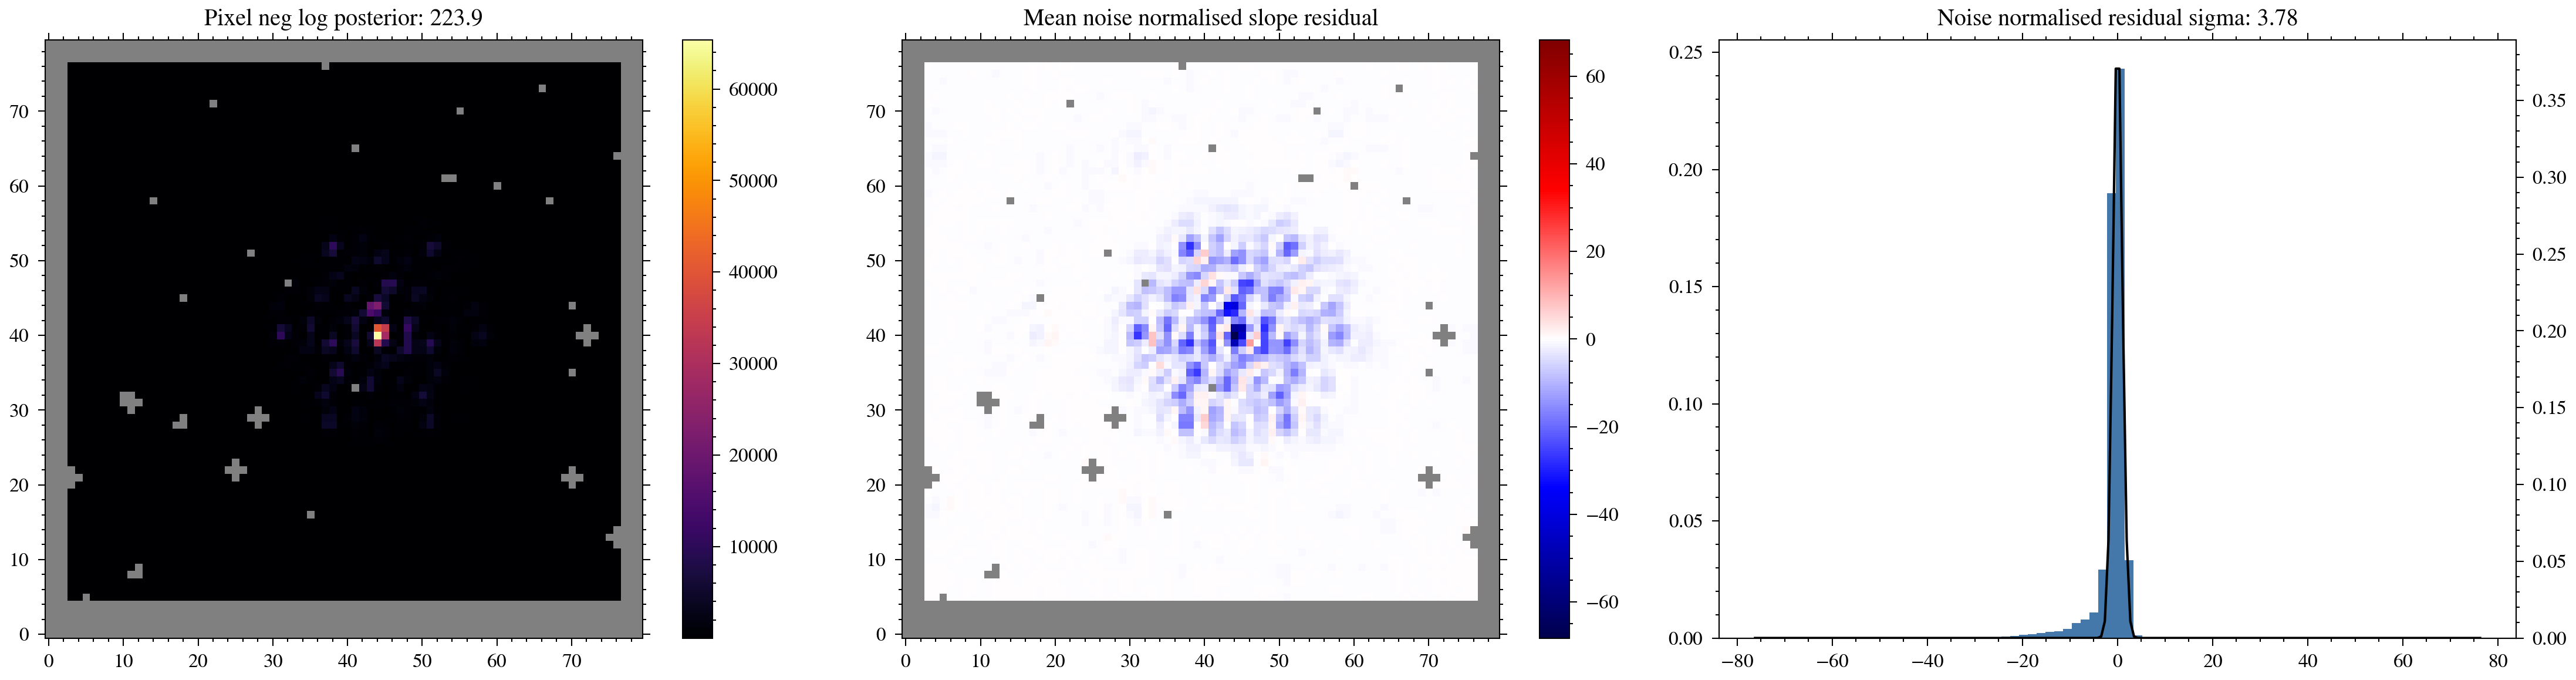

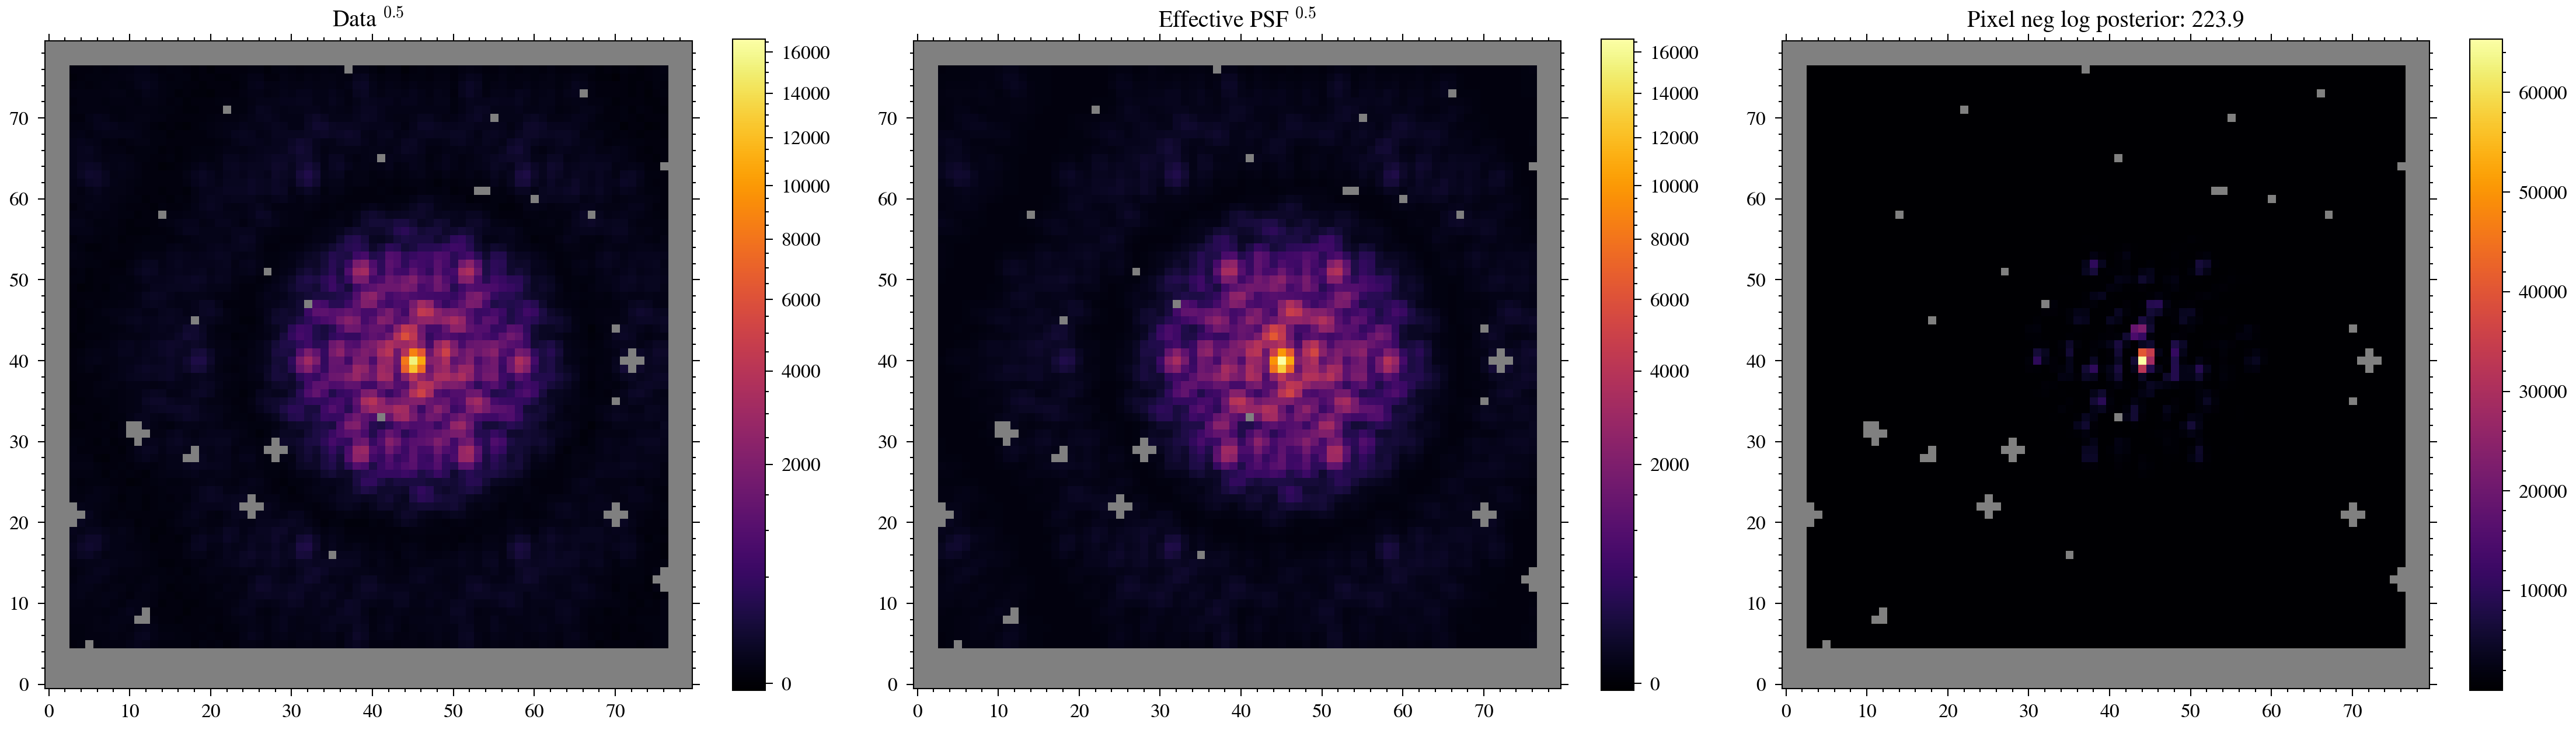

File 01242_004_03_03_1
Star TD-CAL-HD-123991
Filter F430M
nints 507
ngroups 20



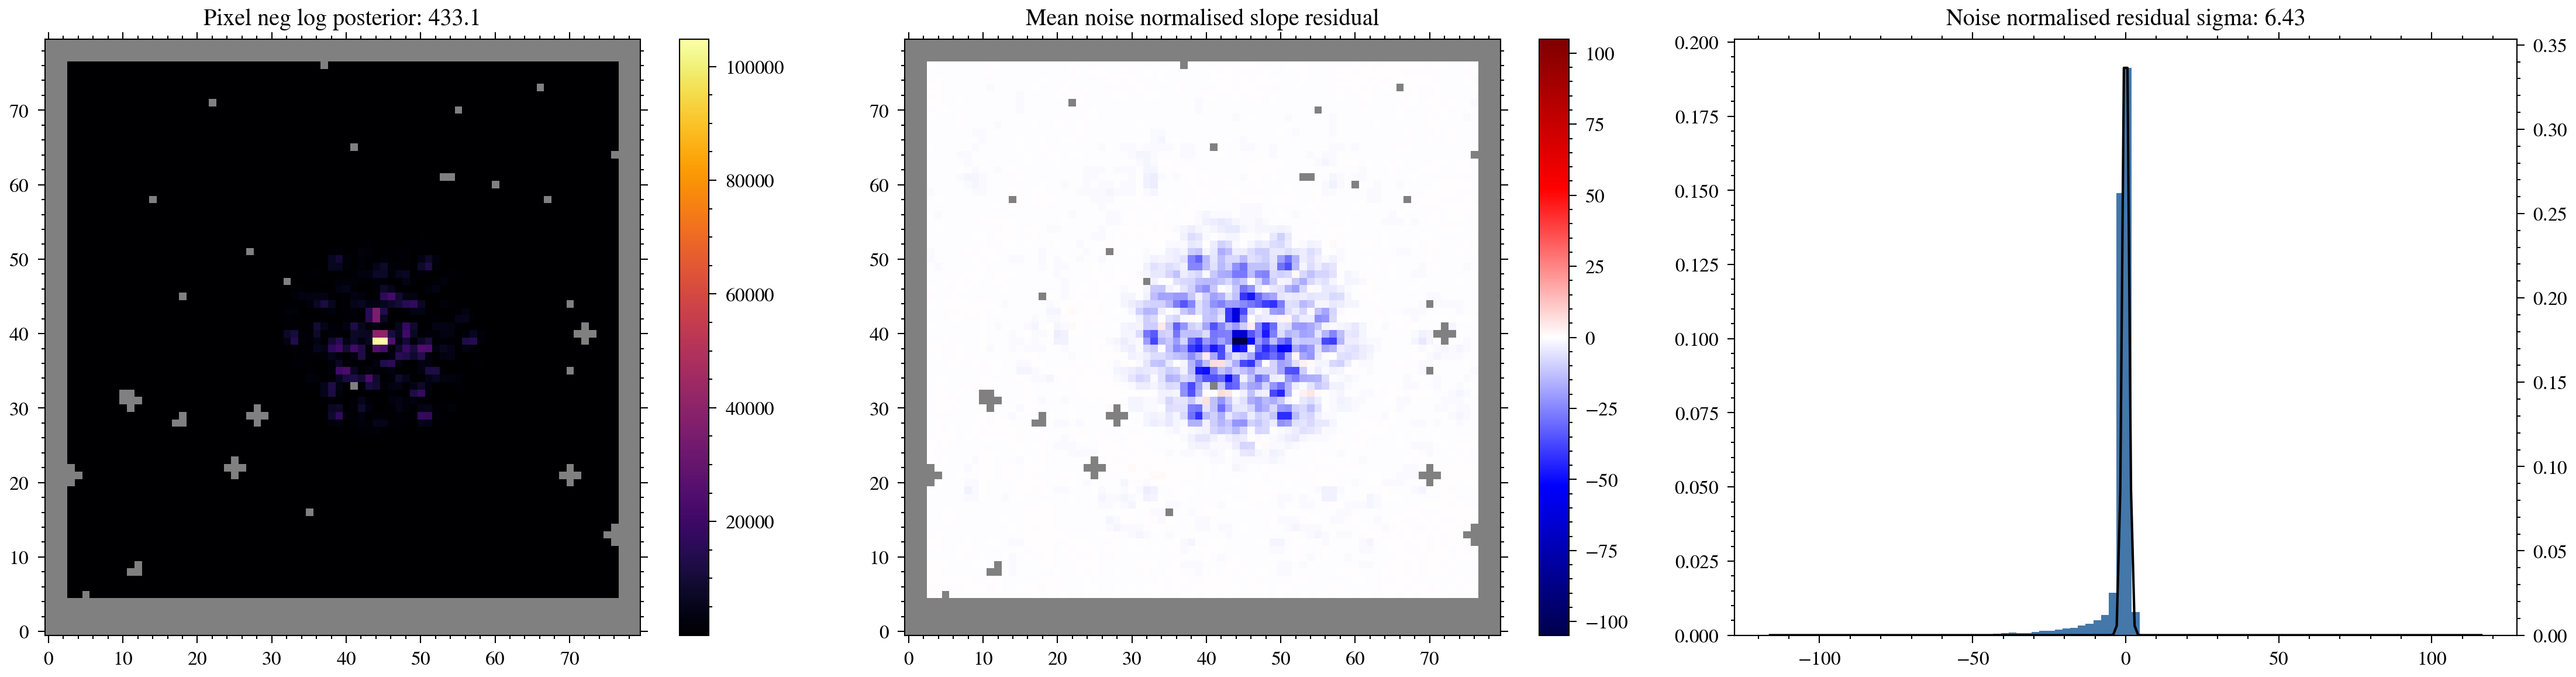

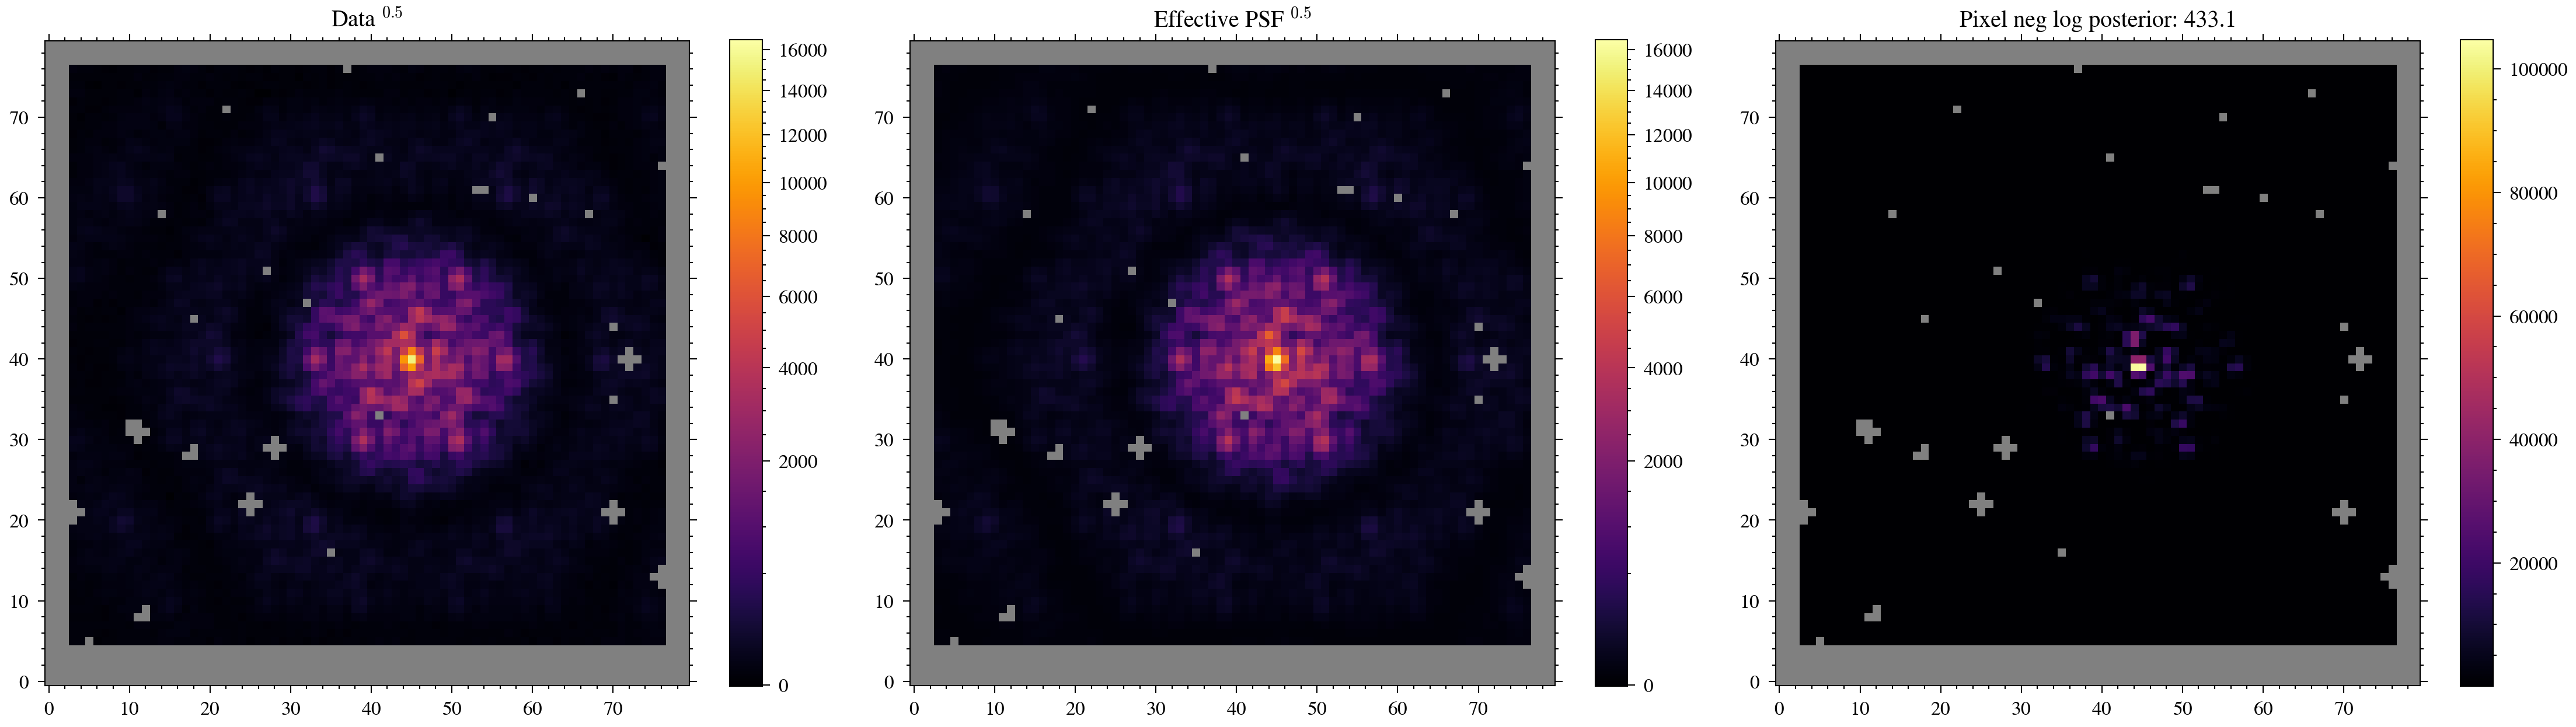

File 01242_004_04_03_1
Star TD-CAL-HD-123991
Filter F380M
nints 612
ngroups 10



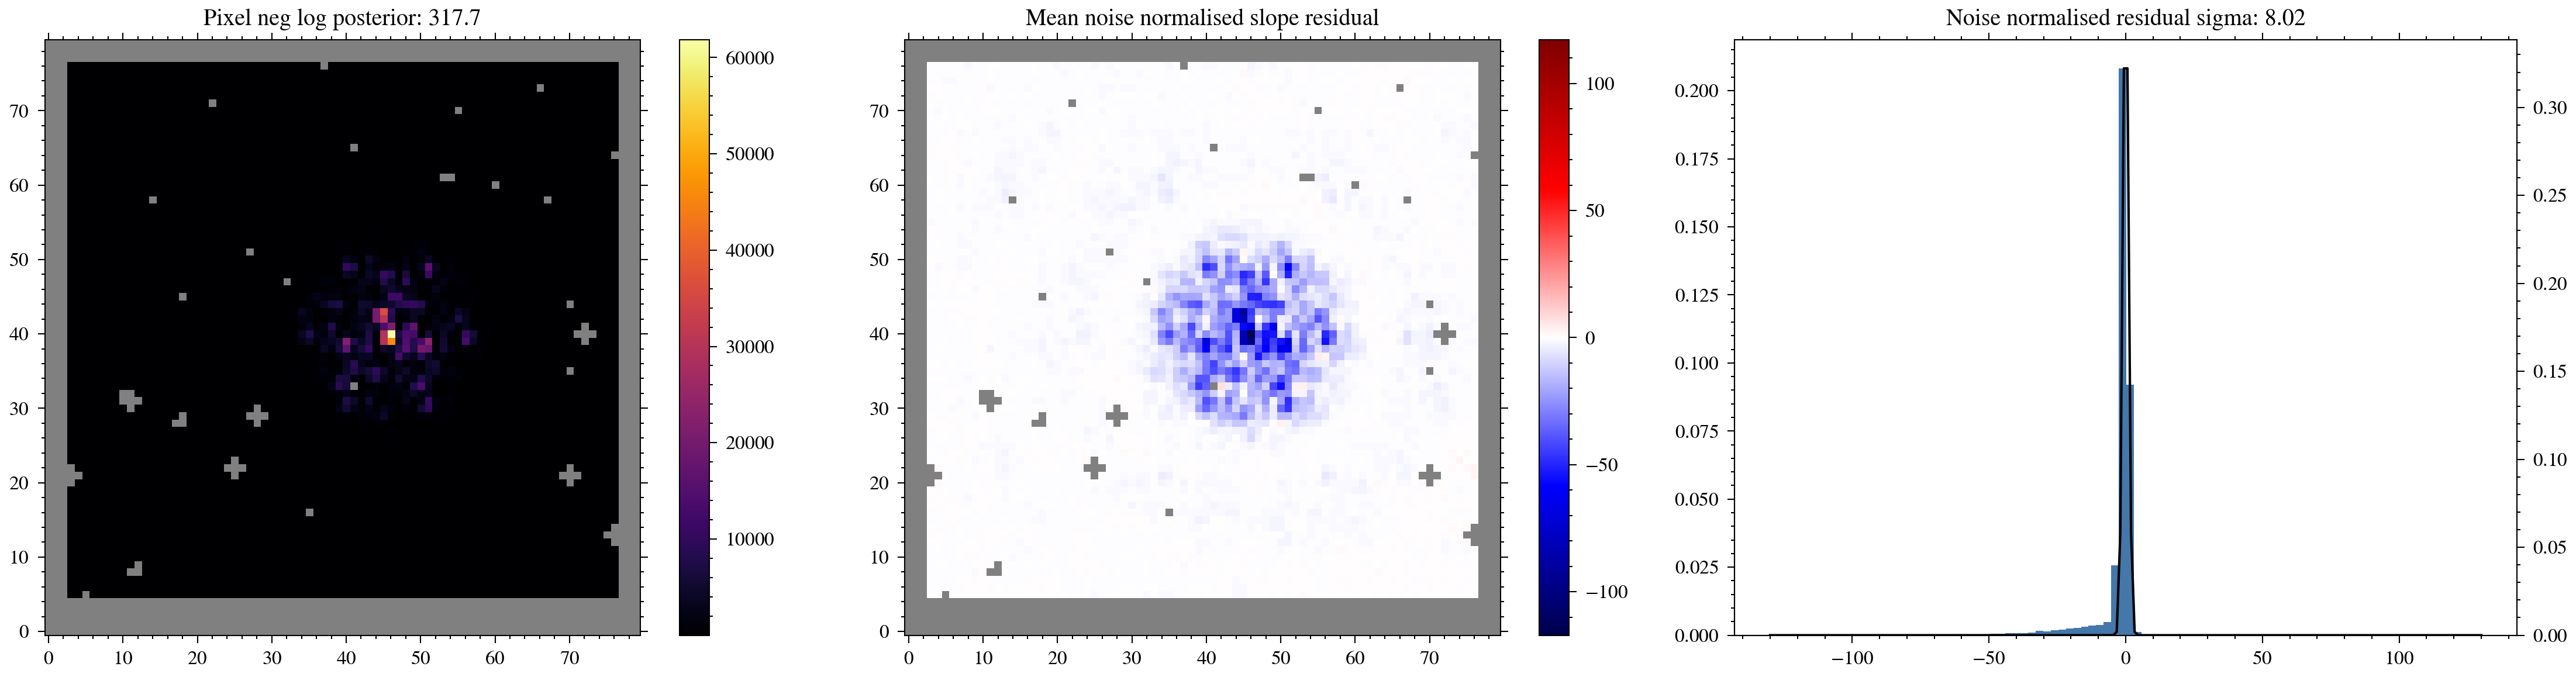

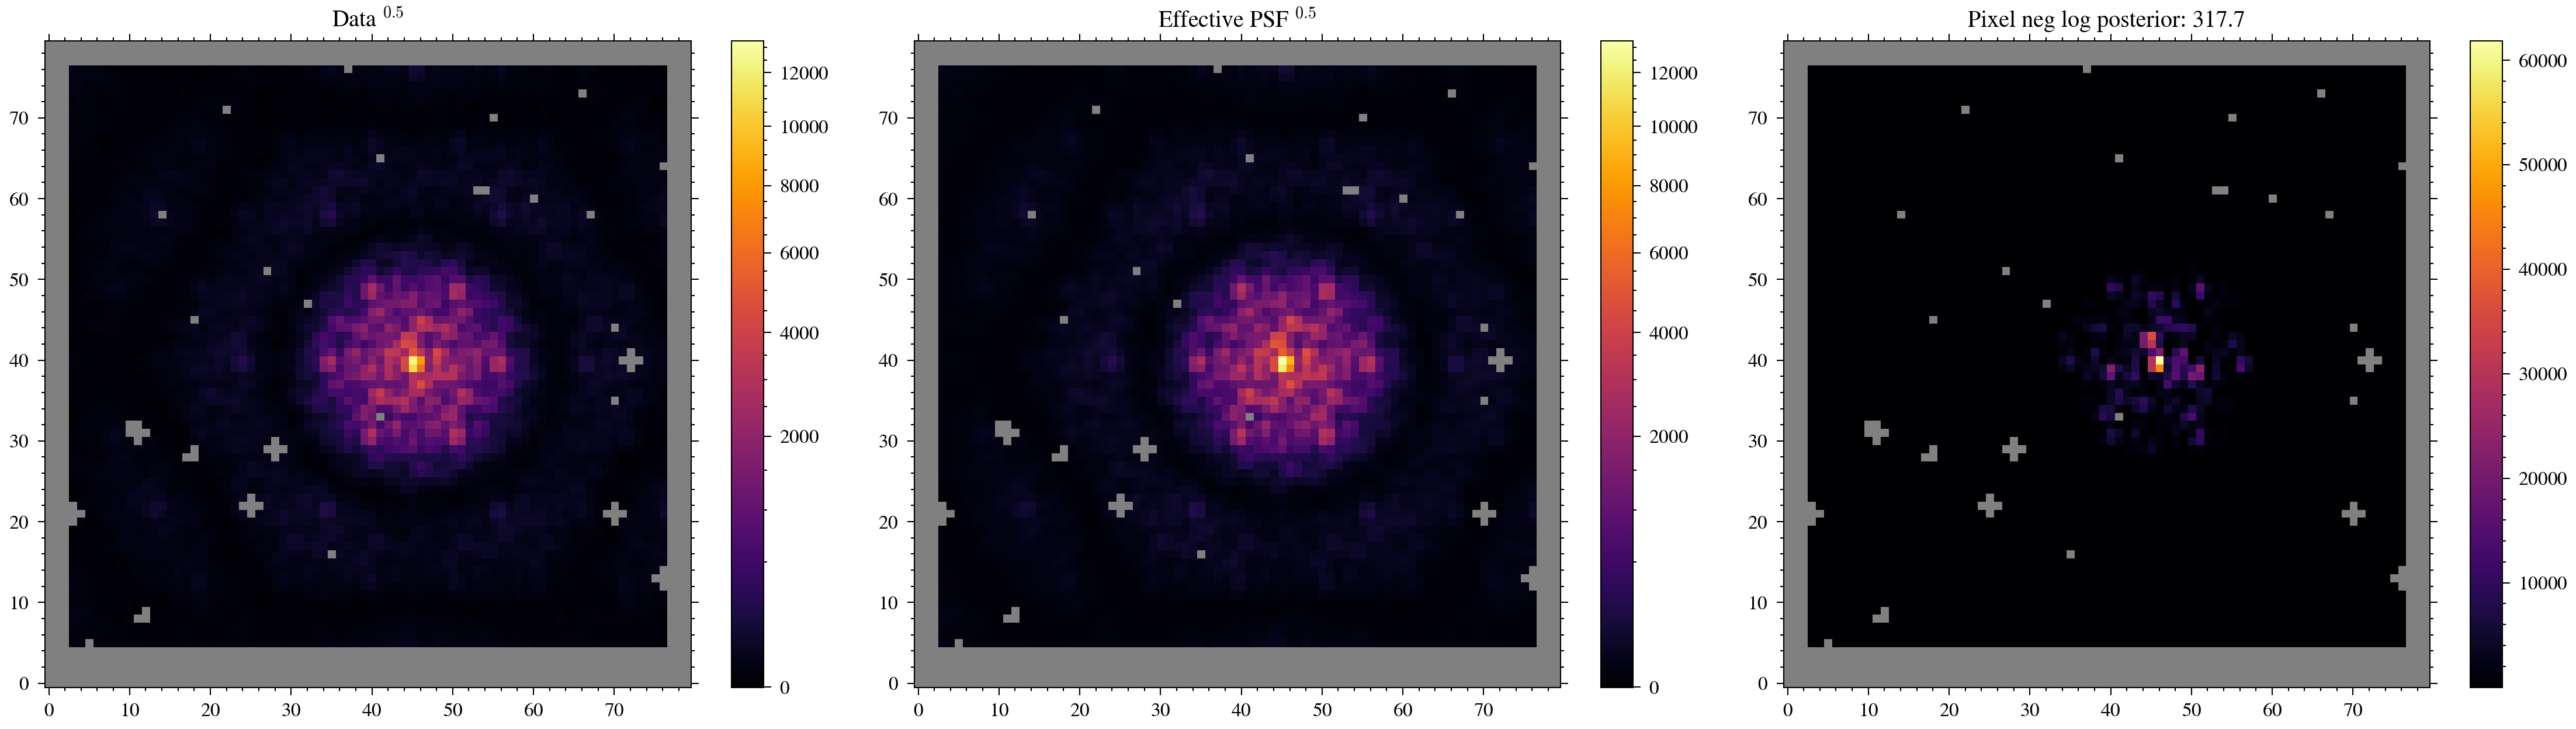

In [7]:
for exp in exposures:
    exp.print_summary()
    amigo.plotting.summarise_fit(model, exp, residuals=True)

## Optimisation Stage 1: Gradient Descent

In [8]:
def norm_fn(model_params, args):
    params = model_params.params

    # NOTE: This normalisation won't work for an arbitrary basis!
    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            distribution = 10**log_dist
            log_dist = np.log10(distribution / distribution.sum())

            params["log_dist"][k] = log_dist

    if "spectra" in params.keys():
        spectra = jax.tree.map(
            lambda x: np.clip(x, a_min=-0.8, a_max=0.8), params["spectra"]
        )
        params["spectra"] = spectra

    return model_params.set("params", params), args

In [9]:
n_epoch = 50

pos_keys = []
spc_keys = []
flx_keys = []
for exp in exposures:
    if not exp.calibrator:
        spc_keys.append(exp.map_param("spectra"))
        pos_keys.append(exp.map_param("positions"))
        flx_keys.append(exp.map_param("fluxes"))

config = {
    # "positions": sgd(8e-2, 0),
    # "fluxes": sgd(5e-2, 0),
    "positions": sgd(1e-7, 0),
    "fluxes": sgd(5e-6, 0),
    "aberrations": sgd(1e-2, 4),
    "spectra": sgd(1e-2, 10),
    # "contrast": sgd(1e-2, 15),
    "contrast": sgd(1e-5, 15),
    "log_dist": sgd(1e-1, 20),
    # "phases": sgd(2e-2, 20),
    # "amplitudes": sgd(2e-2, 20),
}


def grad_fn(model, grads, args):

    # Reduce spectra gradients for the science exposures
    # if "spectra" in config.keys():
    #     grads = grads.multiply(spc_keys, 0.01)

    # if "fluxes" in config.keys():
    #     grads = grads.multiply(flx_keys, np.array([0.1, 50.0]))

    if "positions" in config.keys():
        grads = grads.multiply(pos_keys, 0.1)

    return grads, args


trainer = amigo.fitting.Trainer(
    norm_fn=norm_fn,
    grad_fn=grad_fn,
    cache=os.path.join(amigo_cache, "fishers/"),
)

# Can't do fishers on the PDS70Vis exposure as it needs to scale by
# a singular flux value
trainer = trainer.populate_fishers(
    # model,
    # exposures,
    fish_model,
    fish_exposures,
    hessians=load_dict(cache + "jacobians.npy")["hessian"],
    # parameters=list(config.keys()),
    parameters=[key for key in config.keys() if key not in ["fluxes", "positions"]],
)

print("Number of exposures: ", len(exposures))


# Train the model
# with jax.disable_jit():
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=exposures,
    # batches=exposures,
)

KeyError: contrast not in hessians for 01242_005_02_03_1, skipped
KeyError: log_dist not in hessians for 01242_005_02_03_1, skipped
KeyError: contrast not in hessians for 01242_005_03_03_1, skipped
KeyError: log_dist not in hessians for 01242_005_03_03_1, skipped
KeyError: contrast not in hessians for 01242_005_04_03_1, skipped
KeyError: log_dist not in hessians for 01242_005_04_03_1, skipped
Number of exposures:  6


  0%|          | 0/50 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 1,813.34
Estimated run time: 0:47:49
Full Time: 0:23:07
Final Loss: 138.37


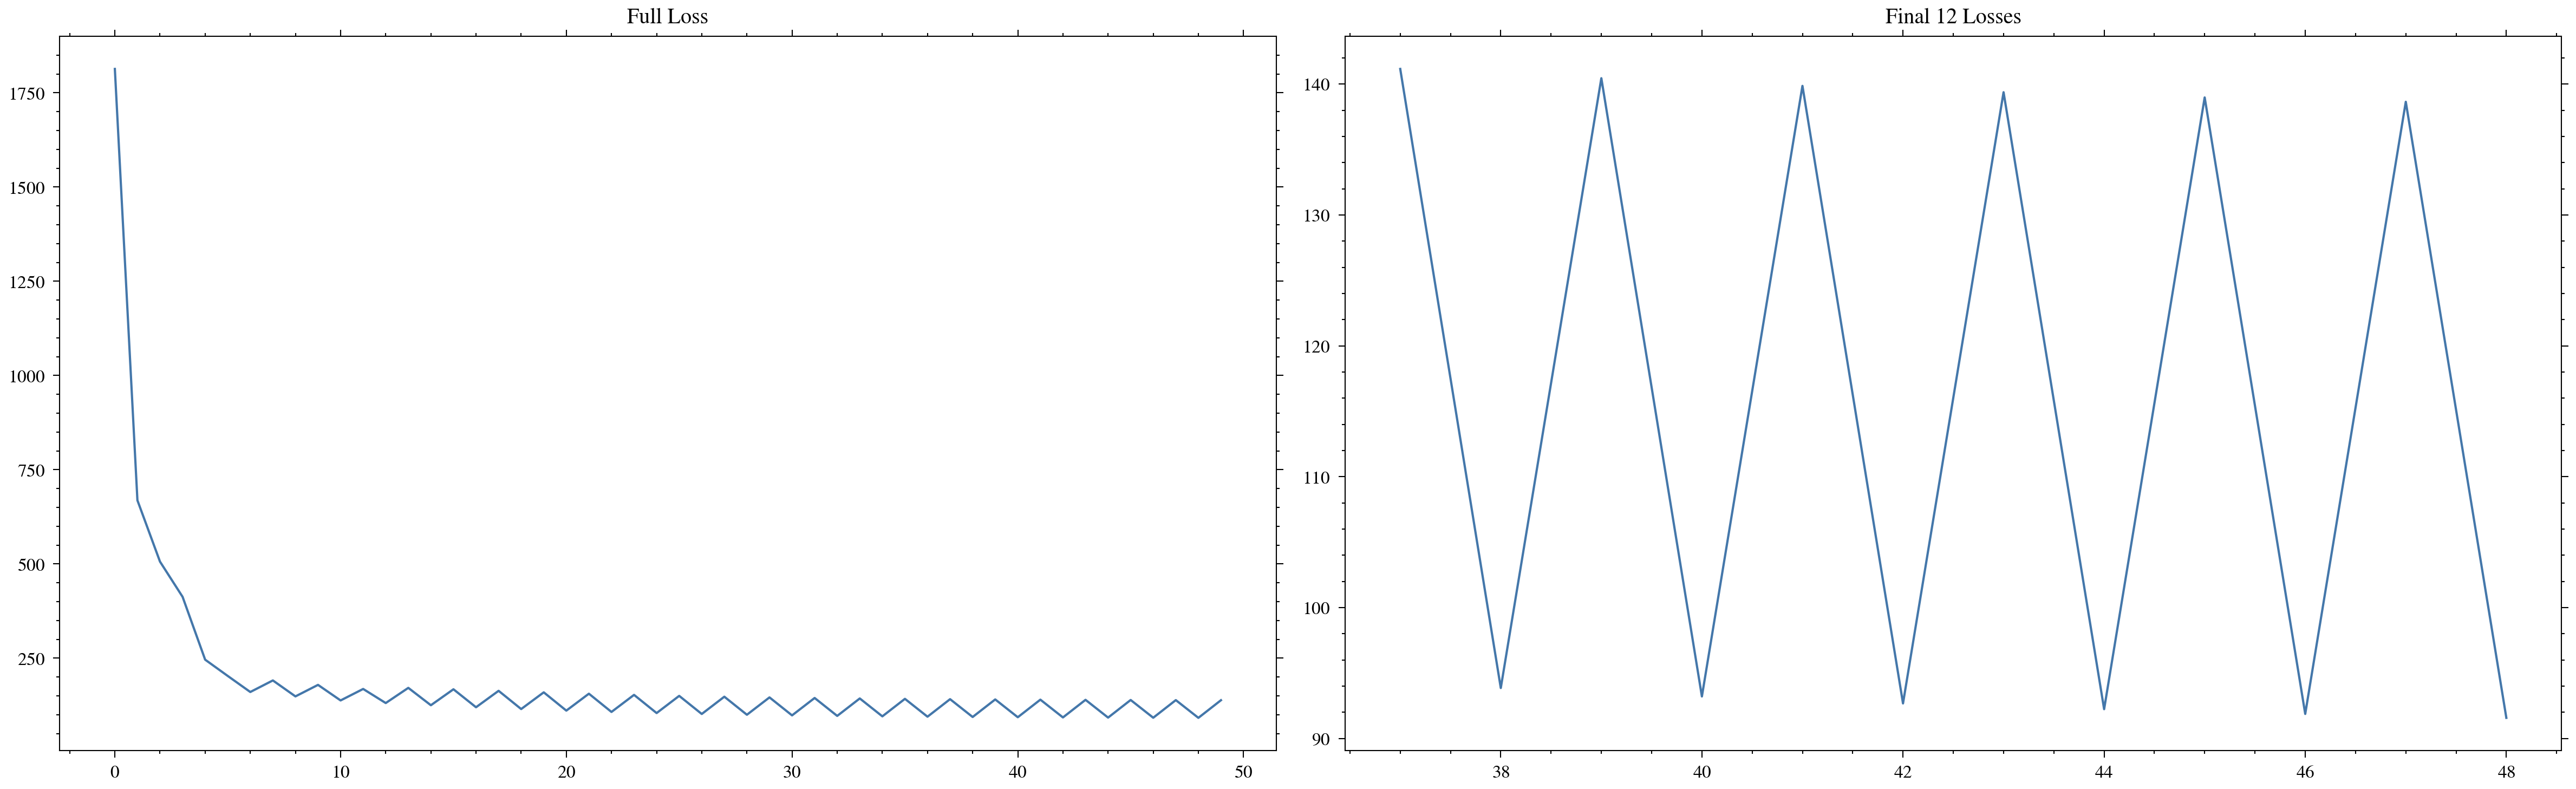

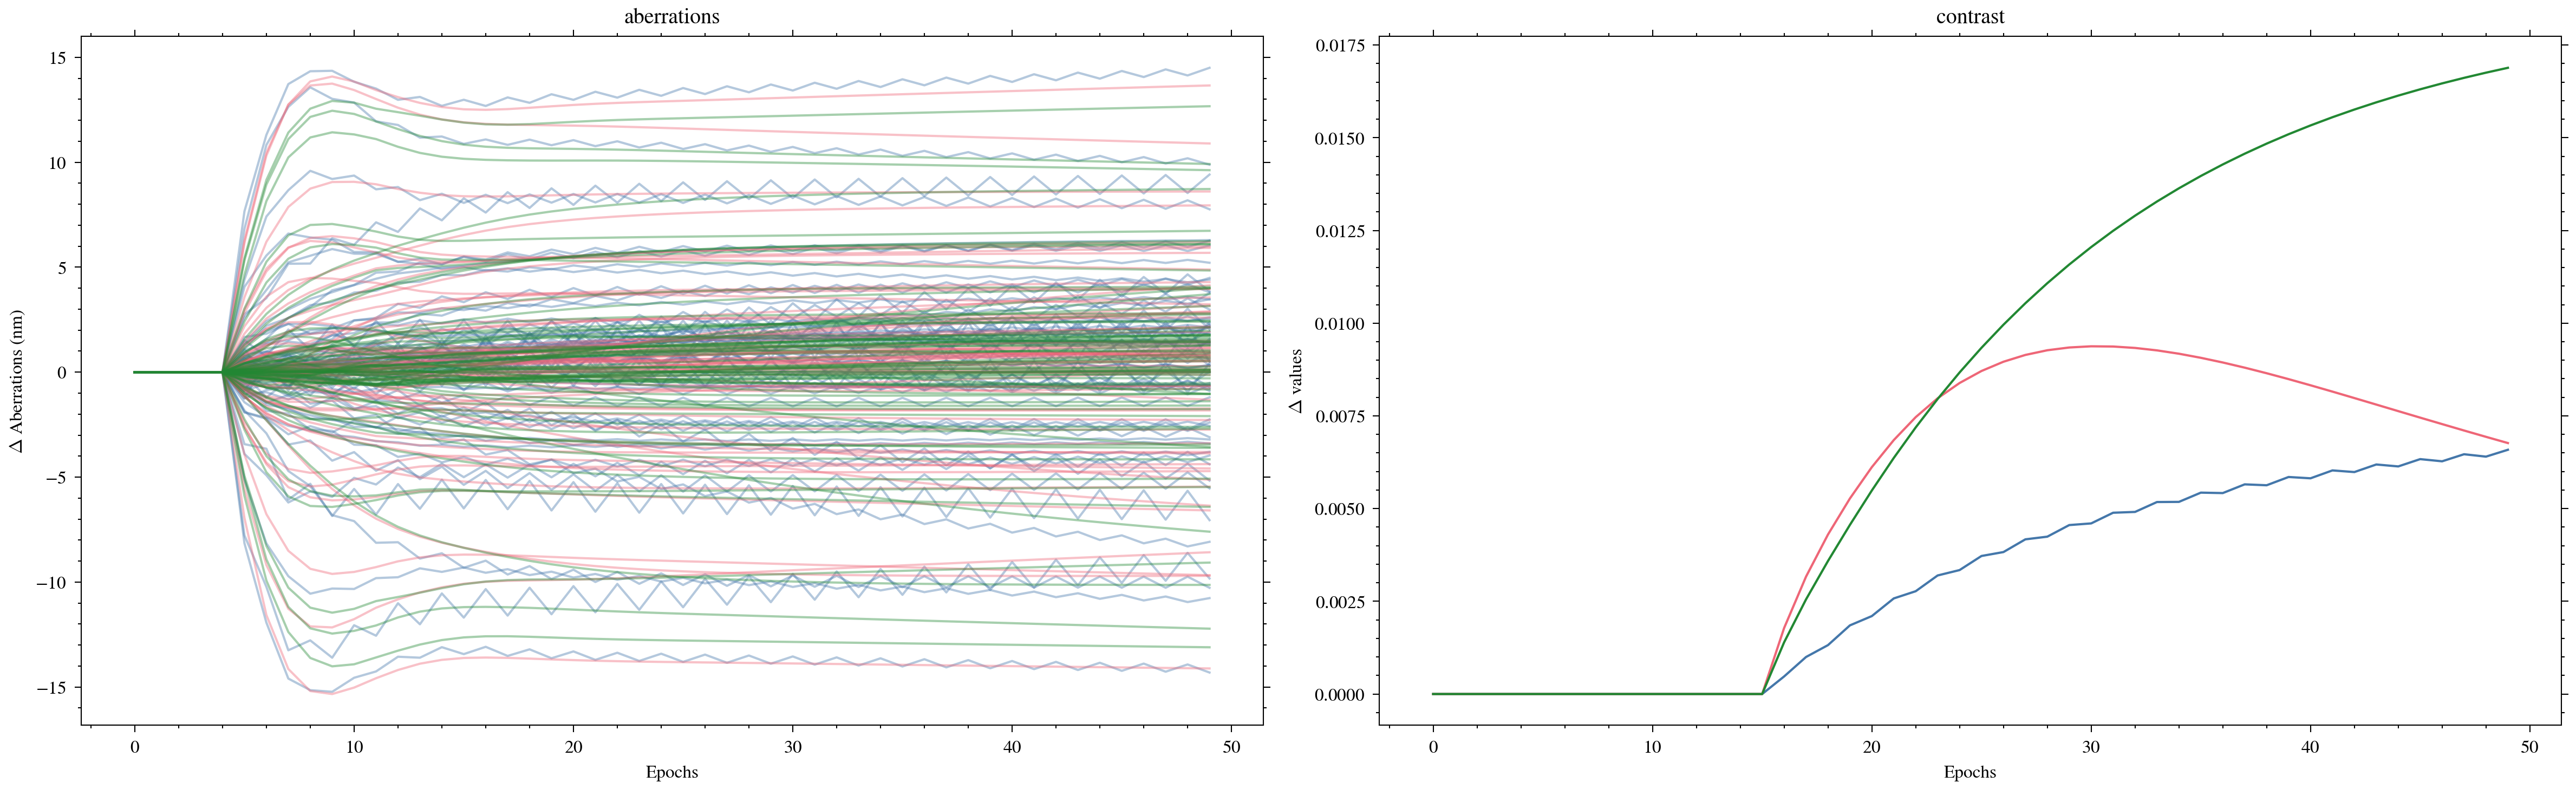

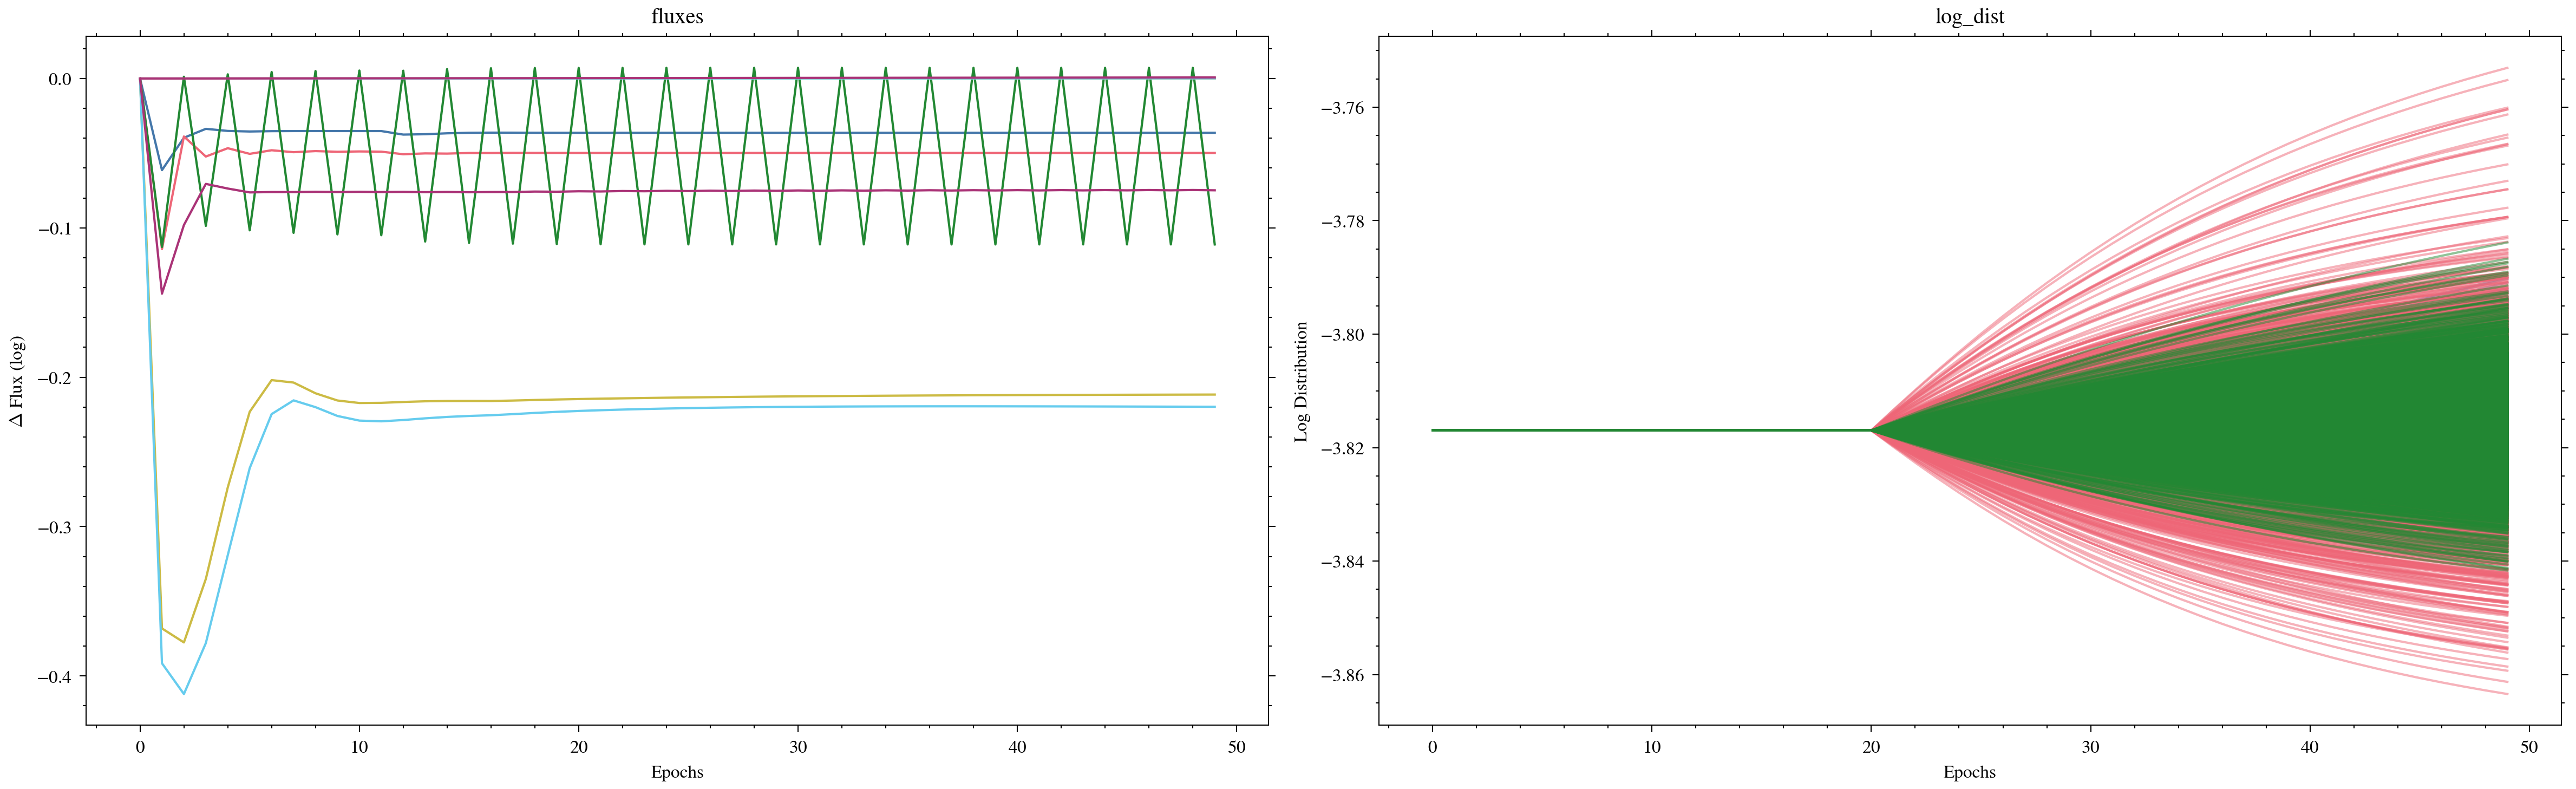

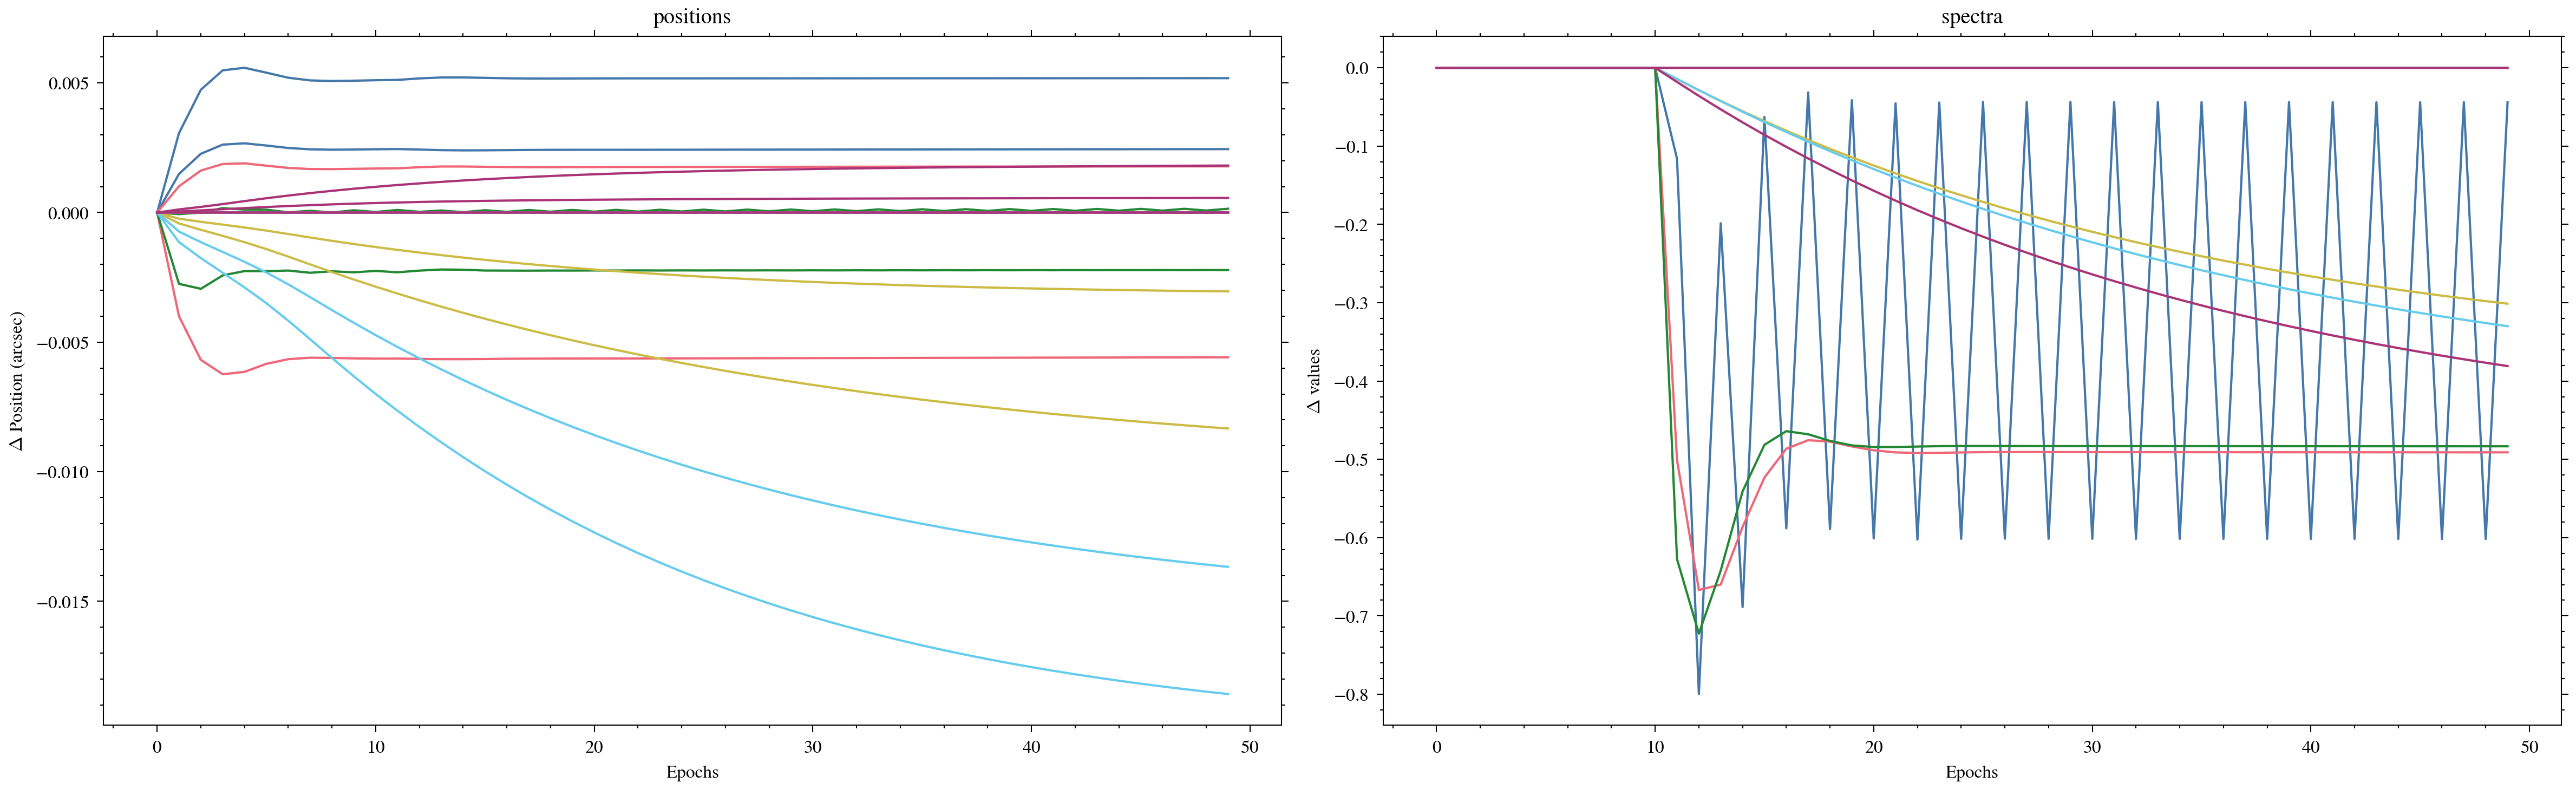

File 01242_005_02_03_1
Star TD-PDS-70
Filter F480M
nints 418
ngroups 96



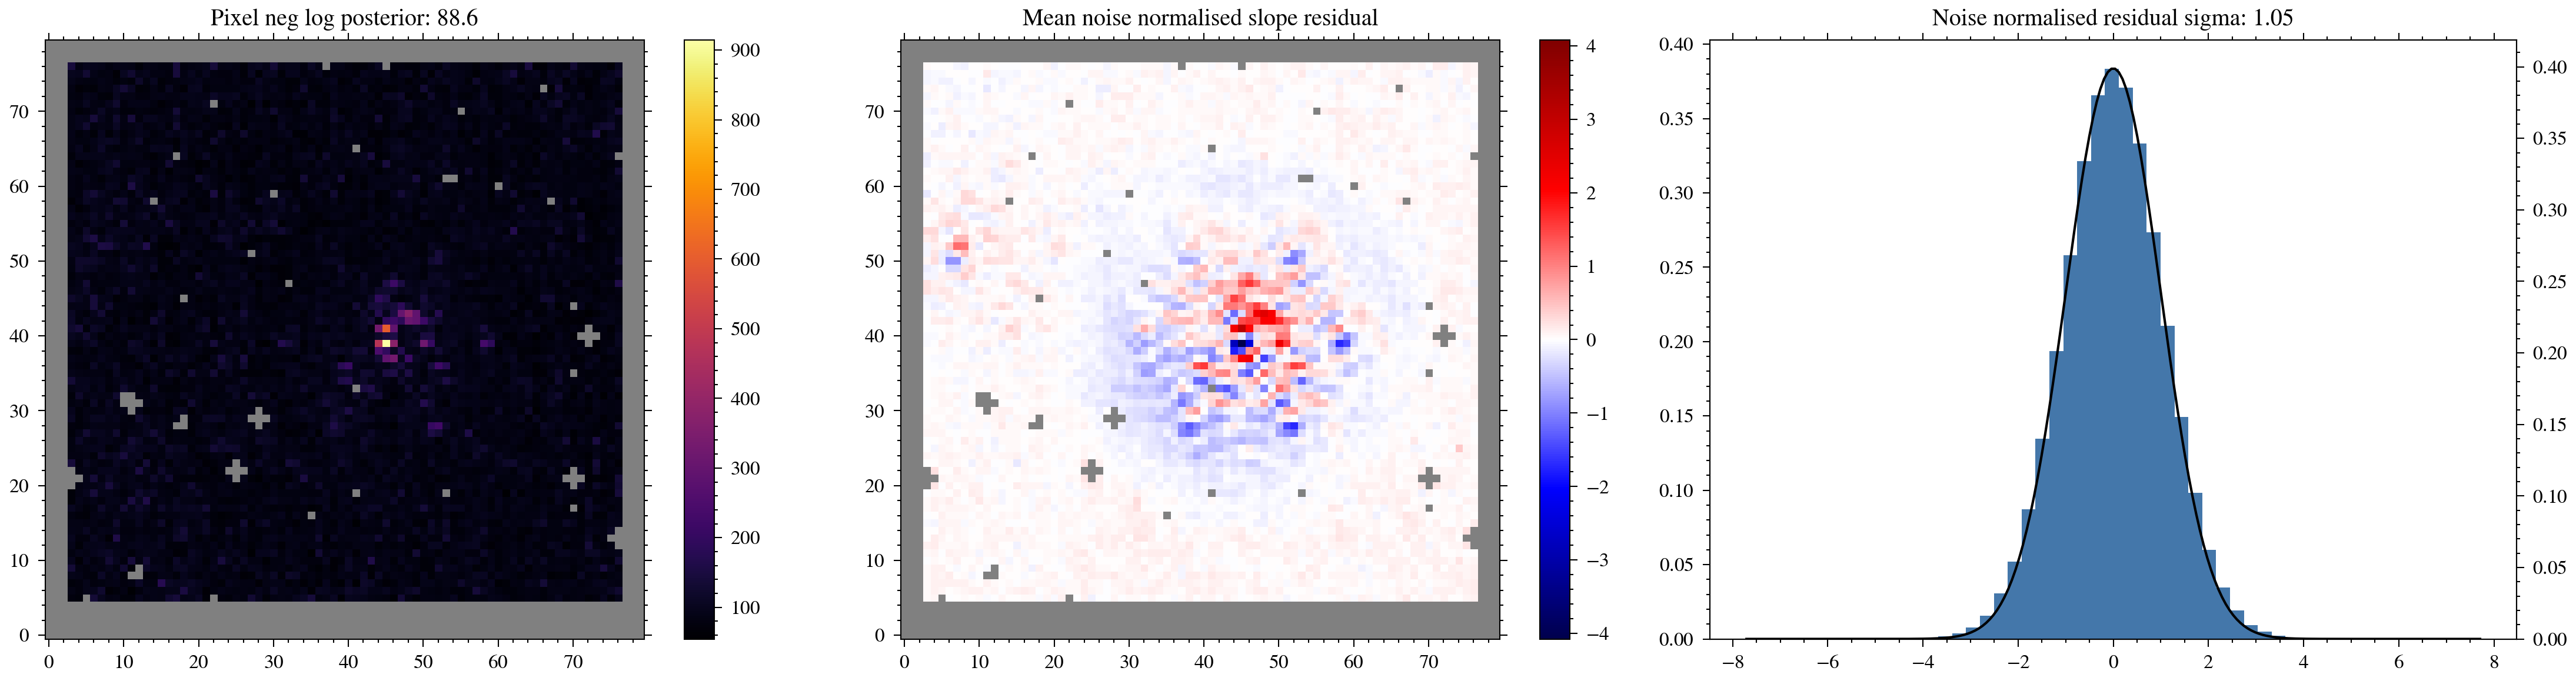

File 01242_005_03_03_1
Star TD-PDS-70
Filter F430M
nints 502
ngroups 64



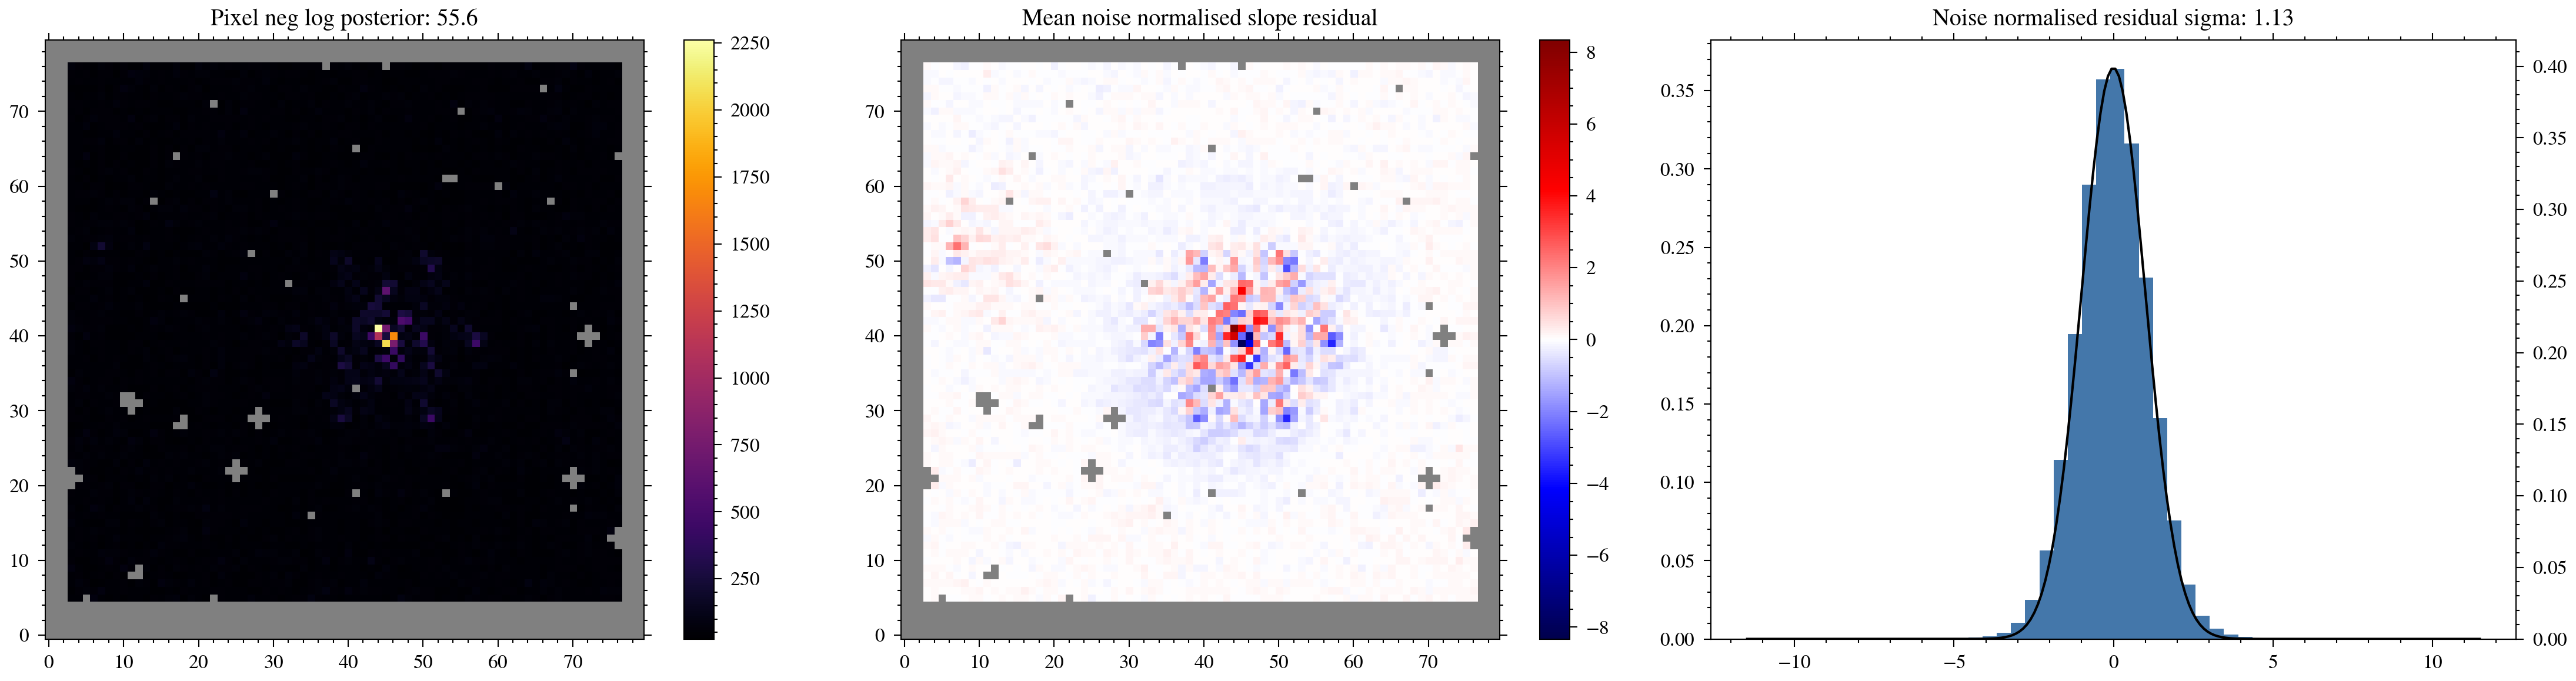

File 01242_005_04_03_1
Star TD-PDS-70
Filter F380M
nints 597
ngroups 49



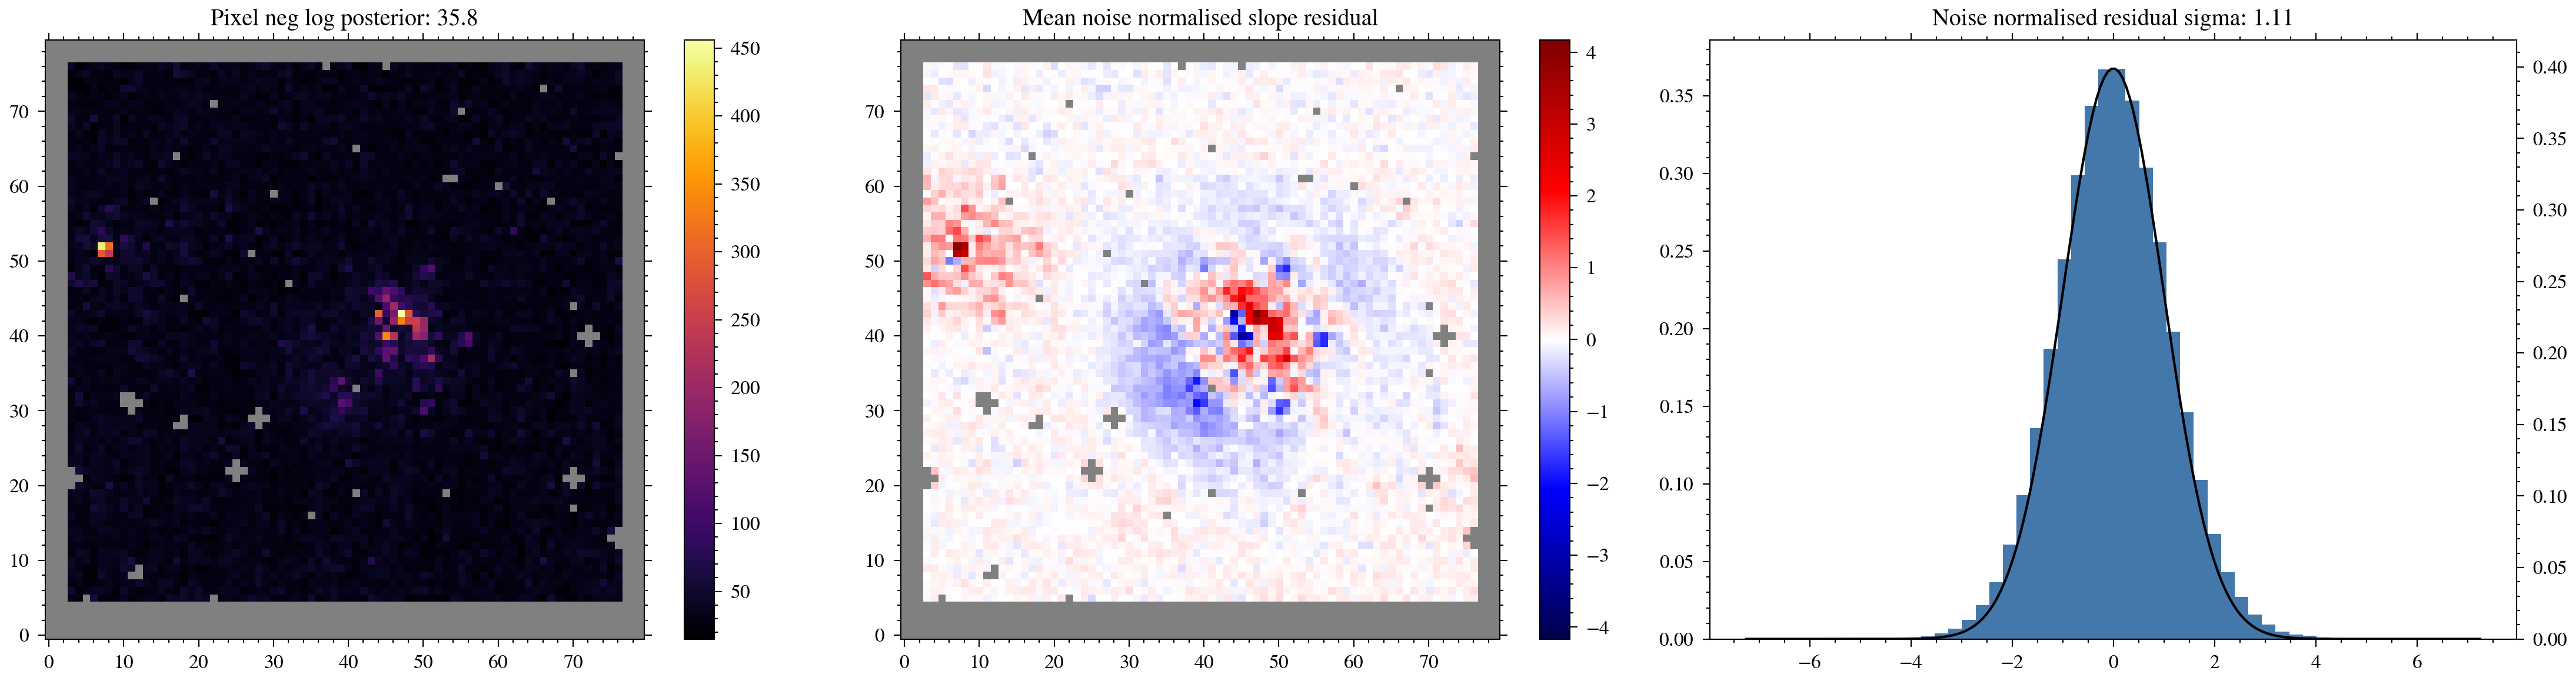

File 01242_004_02_03_1
Star TD-CAL-HD-123991
Filter F480M
nints 418
ngroups 29



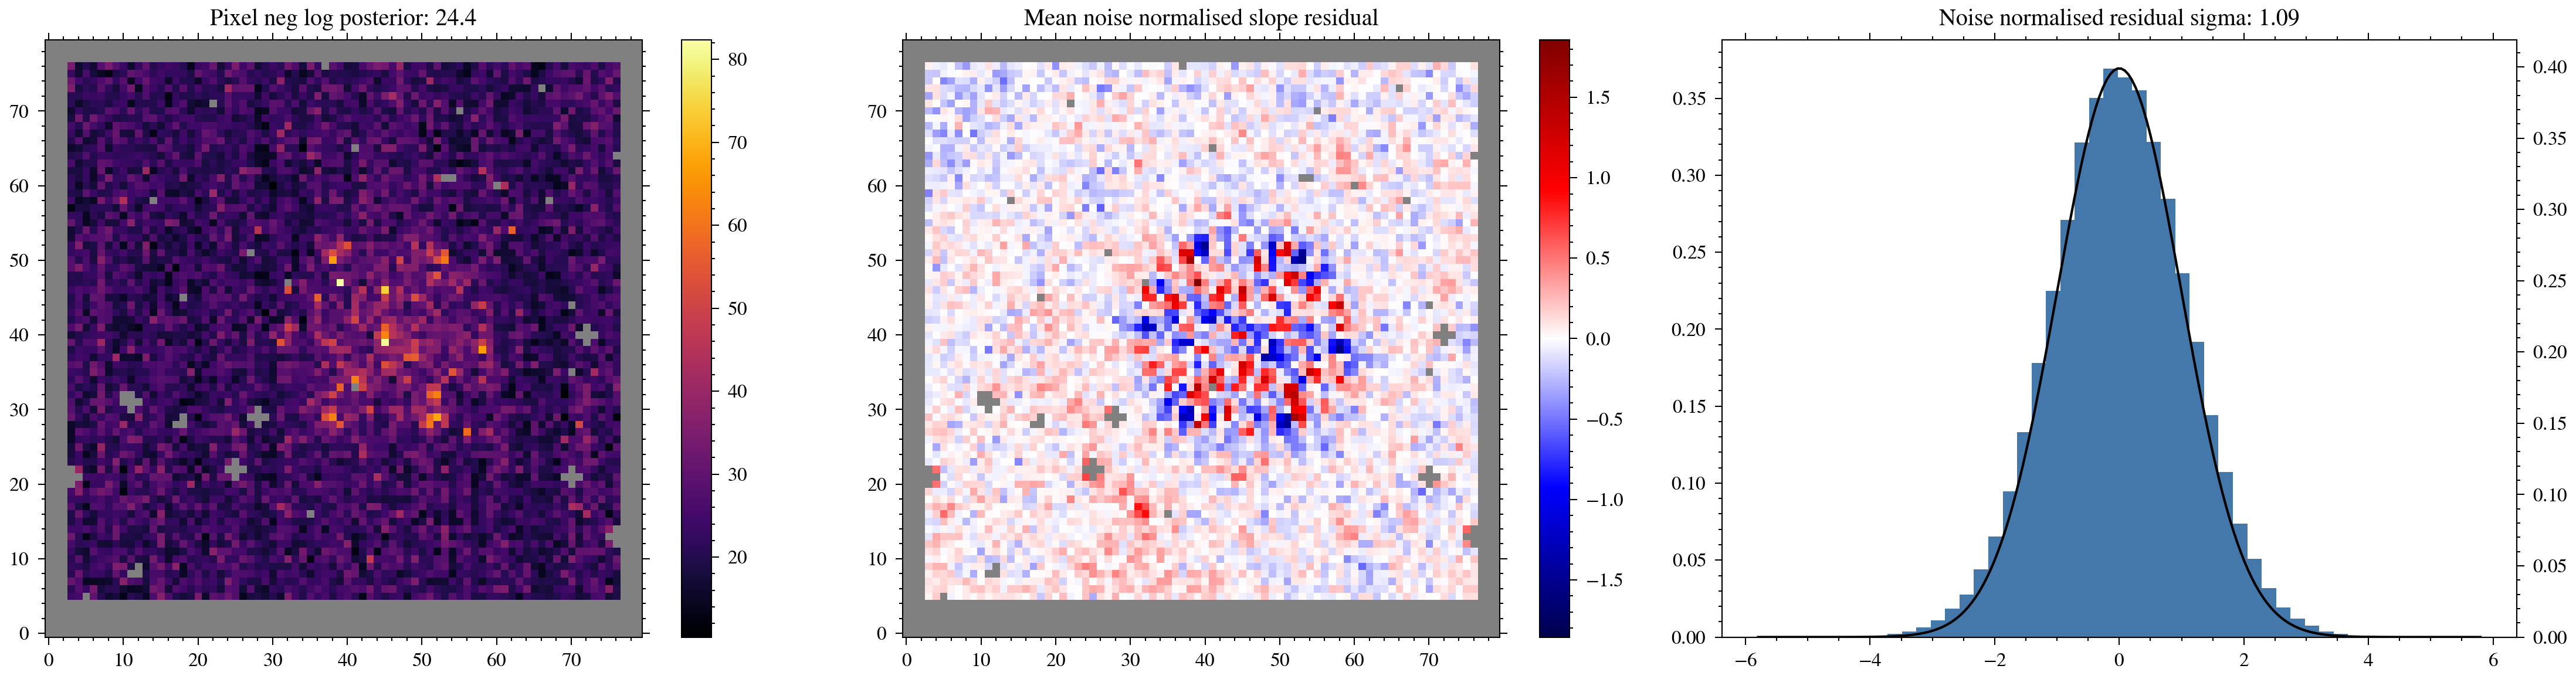

File 01242_004_03_03_1
Star TD-CAL-HD-123991
Filter F430M
nints 507
ngroups 20



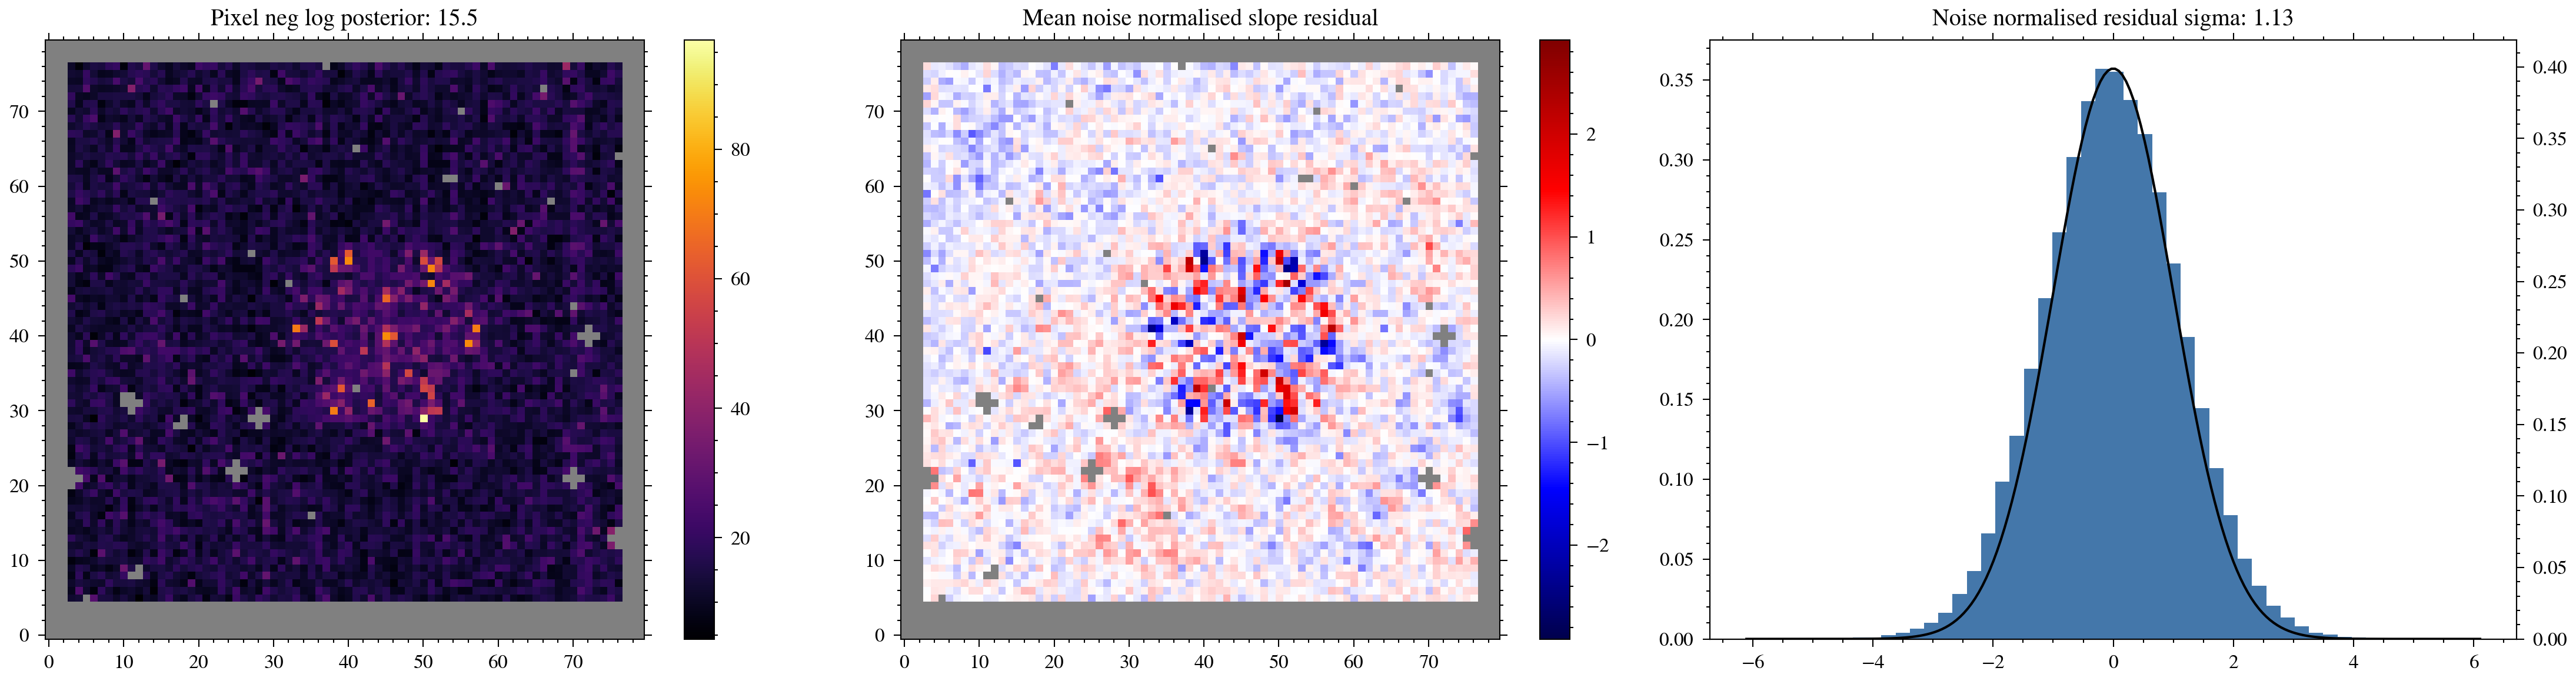

File 01242_004_04_03_1
Star TD-CAL-HD-123991
Filter F380M
nints 612
ngroups 10



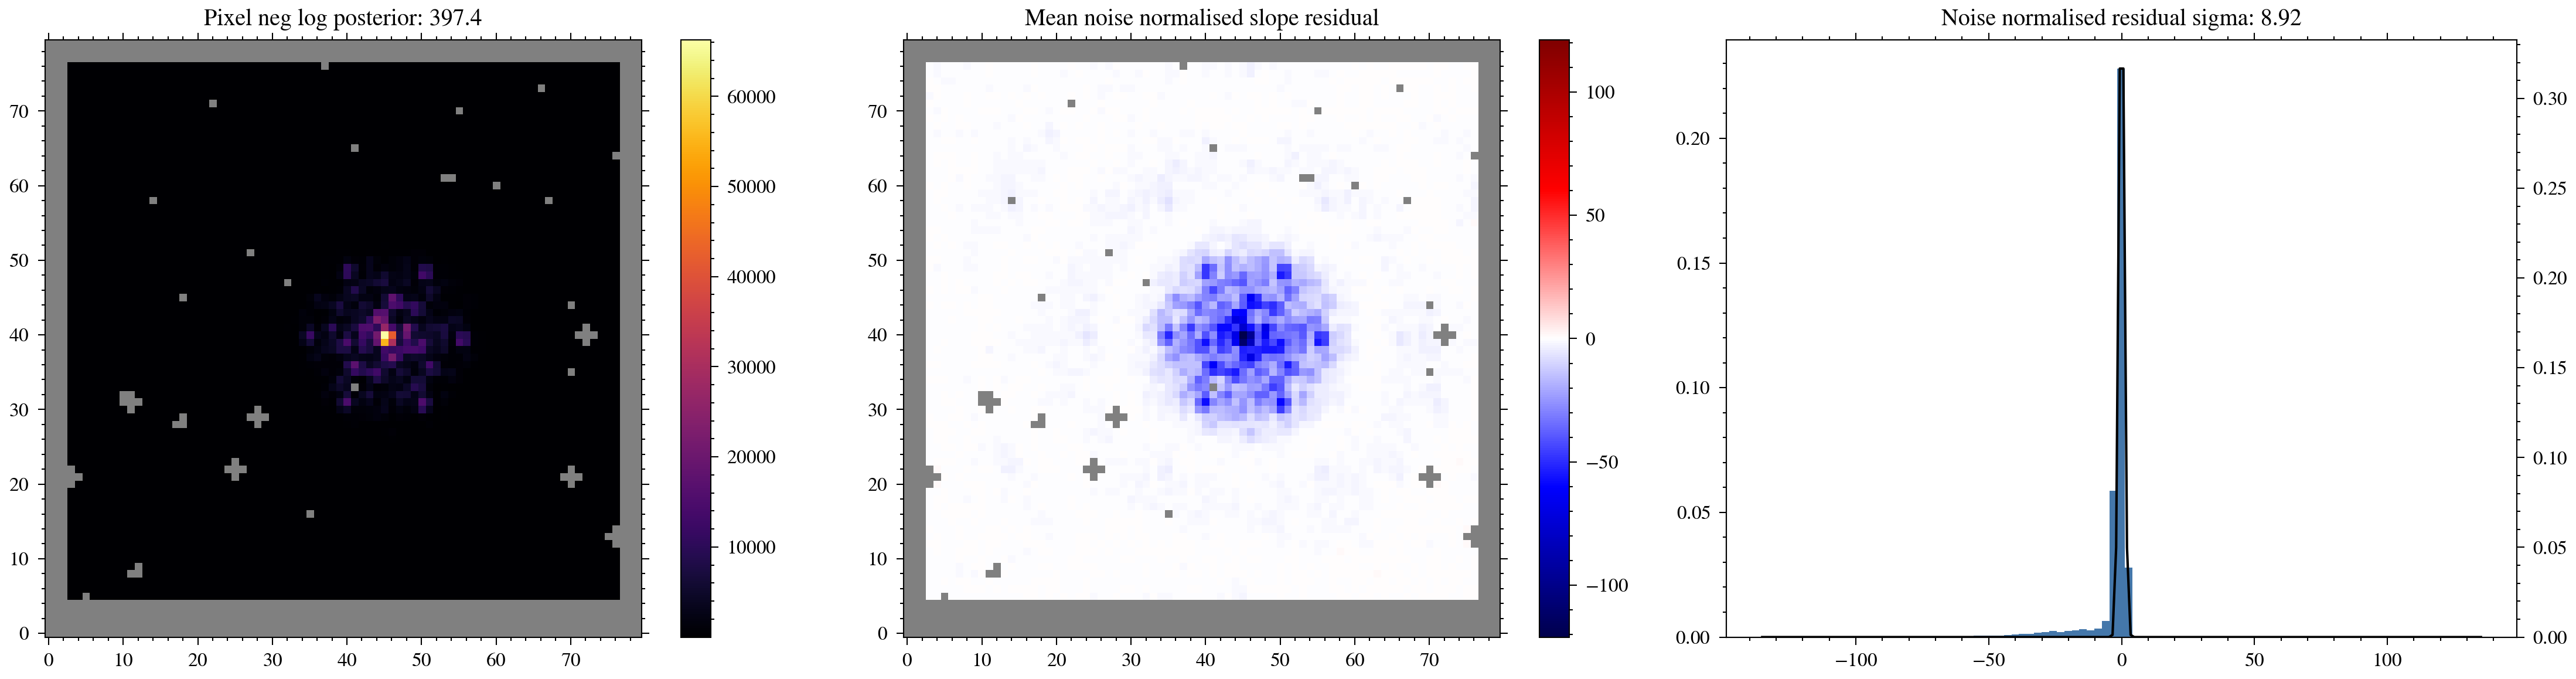

In [10]:
amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

for exp in exposures:
    exp.print_summary()
    amigo.plotting.summarise_fit(result.model, exp)

In [11]:
# stars = list(set([exp.star for exp in exposures]))

# for targ_star in stars:
#     plt.figure(figsize=(10, 4))
#     plt.title(f"{targ_star}")
#     for key, spec in result.model.spectra.items():
#         star, filt = key.split("_")

#         if star != targ_star:
#             continue

#         wavels, filt_weights = model.filters[filt]
#         xs = np.linspace(-1, 1, len(wavels), endpoint=True)
#         spectra_slopes = 1 + spec * xs
#         weights = filt_weights * spectra_slopes  # * wavels

#         #
#         filt_weights = filt_weights / filt_weights.sum()
#         spectra_slopes = spectra_slopes / spectra_slopes.sum()
#         weights = weights / weights.sum()

#         plt.plot(wavels, weights, label="Filter Weights")
#         plt.plot(wavels, spectra_slopes, label="Spectral Weights")
#         plt.plot(wavels, filt_weights, label="Combined Weights")

#     plt.legend()
#     plt.show()

# Optimisation Stage 2: BFGS

In [12]:
import equinox as eqx
import optimistix as optx
from amigo.core_models import ModelParams


def get_proj_mat(fmat):
    """Get the projection matrix for a Fisher matrix"""
    eig_vals, eig_vecs = np.linalg.eig(-fmat)
    return (eig_vals.real**-0.5)[:, None] * eig_vecs.real.T


proj_mats = jtu.map(get_proj_mat, trainer.fishers)


@eqx.filter_jit
def fun(params, args):
    model, exp, model_params, proj_mats, shapes = args

    # Project and add the parameters
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, params)
    model_params = jtu.map(lambda x, y: x + y, model_params, proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, shapes)
    model = model_params.inject(model)

    # Return the loss
    return -np.nanmean(exp.mv_zscore(model))


params = ["amplitudes", "phases", "fluxes", "spectra"]
final_model = result.model

args_out = {}
sols_out = {}
for exp in exposures:
    opt_params = {}
    fishers = {}
    shapes = {}
    for param in params:
        key = exp.map_param(param)
        shapes[key] = final_model.get(key).shape
        opt_params[key] = final_model.get(key).flatten()
        fishers[key] = trainer.fishers[f"{exp.key}.{param}"]

    shapes = ModelParams(shapes)
    model_params = ModelParams(opt_params)
    initial_params = jtu.map(lambda x: np.zeros_like(x), model_params)
    proj_mats = jtu.map(get_proj_mat, ModelParams(fishers))
    proj_mats = jtu.map(lambda x: np.where(np.isnan(x) | np.isinf(x), 0, x), proj_mats)

    args = (final_model, exp, model_params, proj_mats, shapes)
    args_out[exp.key] = args

    try:
        print("Initial loss:", fun(initial_params, args))
    except Exception as e:
        print(f"Skipped {exp.key}")
        continue
    solver = optx.BFGS(rtol=1e-6, atol=1e-6)
    sol = optx.minimise(fun, solver, initial_params, args, throw=False, max_steps=2048)
    sols_out[exp.key] = sol

    print("Final loss:", fun(sol.value, args))
    print(sol.stats["num_steps"], sol.state.num_accepted_steps)
    print(optx.RESULTS[sol.result])
    print()

KeyError: "key: amplitudes not found in object: <class 'dorito.models.ResolvedAmigoModel'>"

In [ ]:
for filt in ["F380M", "F430M", "F480M"]:
    for exp in exposures:
        if exp.filter == filt:
            exp_type = "Calibrator" if exp.calibrator else "Science"
            print(exp.filter, exp_type, exp.star, exp.ngroups)
            amigo.plotting.summarise_fit(final_model, exp)